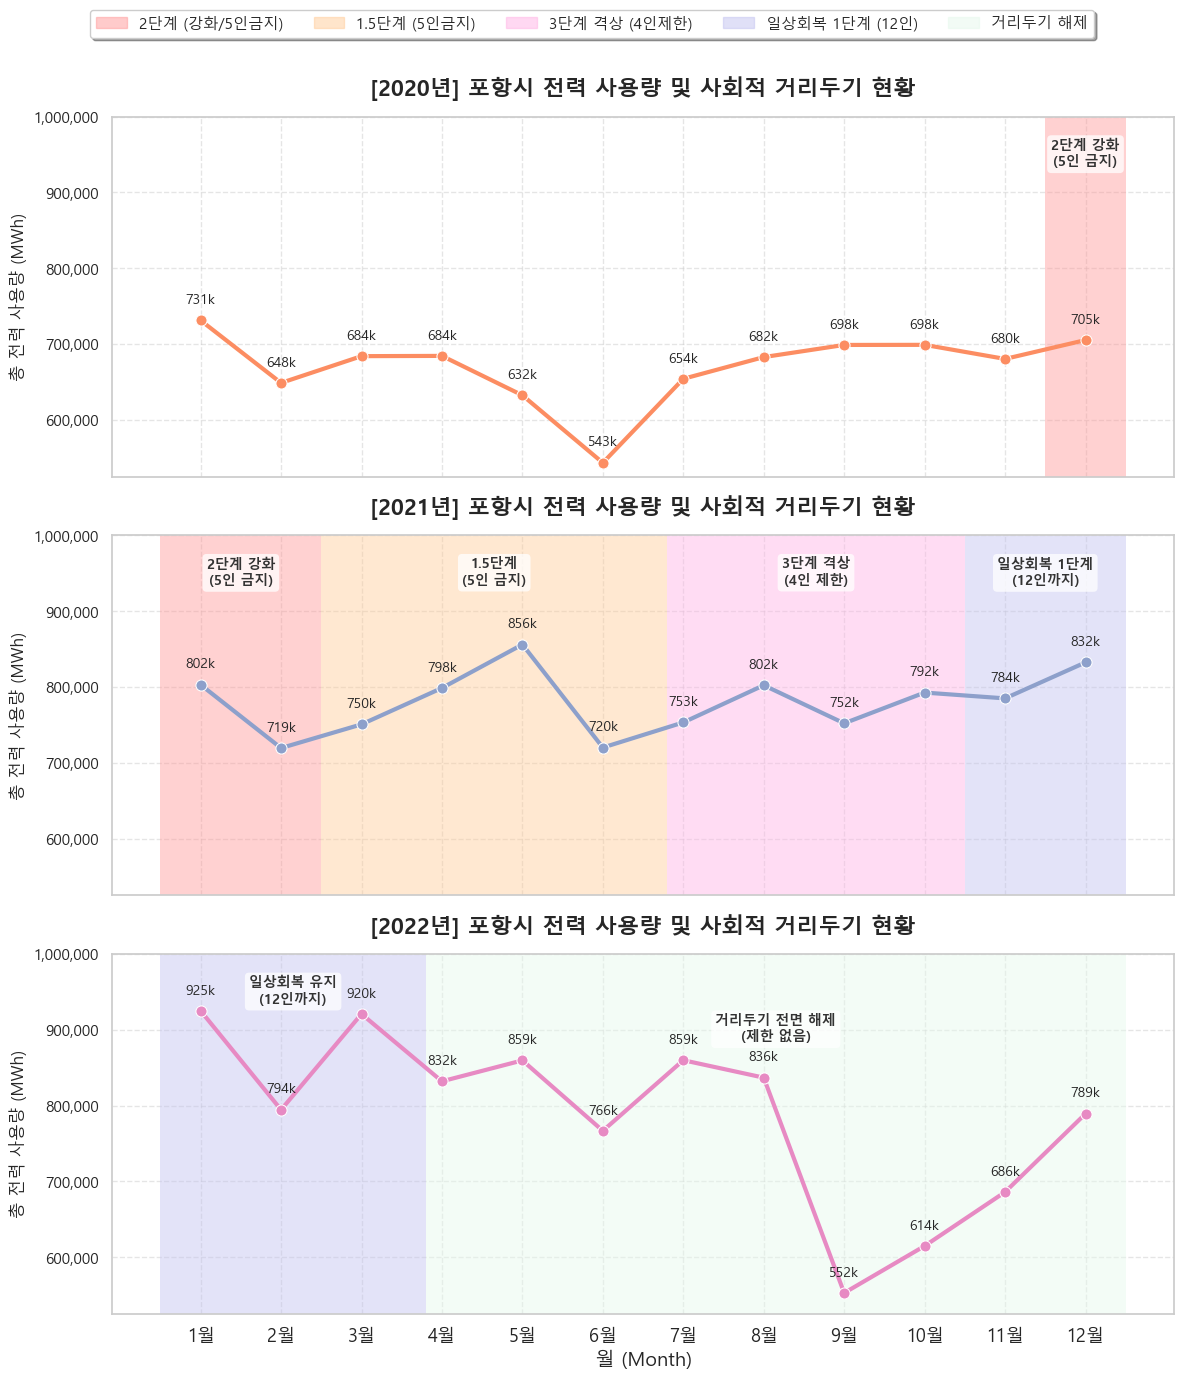

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

# 1. 폰트 및 시각화 환경 설정
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 2. 데이터 불러오기 및 전처리 (새로운 CSV 파일에 맞게 초간단 수정!)
try:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='cp949')

# 보고 싶은 핵심 연도 설정
years = [2020, 2021, 2022]

# 시각화를 위해 1월~12월 데이터를 연도별 컬럼으로 정리
total_usage = pd.DataFrame({'월': range(1, 13)})

for year in years:
    # 해당 연도 데이터만 필터링 후 월 오름차순 정렬
    year_data = df[df['연도'] == year].sort_values('월')
    total_usage[str(year)] = year_data['총사용량'].values

# 3. 거리두기 표 기반 구간 및 색상 재설정
COLOR_P1 = '#ff9999' # 2단계 (강화)
COLOR_P2 = '#ffcc99' # 1.5단계
COLOR_P3 = '#ffb3e6' # 3단계
COLOR_P4 = '#c2c2f0' # 일상회복 1단계
COLOR_P5 = '#e6f9ec' # 거리두기 해제

distancing_periods = {
    '2020': [
        (11.5, 12.5, COLOR_P1, '2단계 강화\n(5인 금지)') 
    ],
    '2021': [
        (0.5, 2.5, COLOR_P1, '2단계 강화\n(5인 금지)'),    
        (2.5, 6.8, COLOR_P2, '1.5단계\n(5인 금지)'),        
        (6.8, 10.5, COLOR_P3, '3단계 격상\n(4인 제한)'),      
        (10.5, 12.5, COLOR_P4, '일상회복 1단계\n(12인까지)') 
    ],
    '2022': [
        (0.5, 3.8, COLOR_P4, '일상회복 유지\n(12인까지)'),    
        (3.8, 12.5, COLOR_P5, '거리두기 전면 해제\n(제한 없음)') 
    ]
}

# 4. 시각화 그리기
fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)
line_colors = sns.color_palette("Set2", 5)[1:4] 

for i, year in enumerate([str(y) for y in years]):
    ax = axes[i]
    
    # ★ 핵심 수정 파트: Y축 리밋(limit) 고정 ★
    ax.set_ylim(525000, 1000000)
    
    # 배경색(axvspan) 및 라벨 달기
    if year in distancing_periods:
        for start, end, color, label in distancing_periods[year]:
            ax.axvspan(start, end, color=color, alpha=0.45, lw=0)
            
            # Y축이 고정되었으므로 글씨 위치를 일정한 높이(97만 부근)에 고정
            y_pos = 970000 if '해제' not in label else 920000
            
            ax.text((start+end)/2, y_pos, label, 
                    ha='center', va='top', fontsize=10, fontweight='bold', color='#333333', 
                    bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.3'))

    # 선 그래프 그리기
    sns.lineplot(data=total_usage, x='월', y=year, marker='o', ax=ax, color=line_colors[i], linewidth=3, markersize=8)
    
    ax.set_title(f'[{year}년] 포항시 전력 사용량 및 사회적 거리두기 현황', fontsize=16, fontweight='bold', pad=15)
    ax.set_ylabel('총 전력 사용량 (MWh)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    
    for x, y in zip(total_usage['월'], total_usage[year]):
        ax.annotate(f'{int(y/1000)}k', (x, y), textcoords="offset points", xytext=(0,12), ha='center', fontsize=10)

# 범례(Legend) 붙이기
legend_patches = [
    mpatches.Patch(color=COLOR_P1, alpha=0.5, label='2단계 (강화/5인금지)'),
    mpatches.Patch(color=COLOR_P2, alpha=0.5, label='1.5단계 (5인금지)'),
    mpatches.Patch(color=COLOR_P3, alpha=0.5, label='3단계 격상 (4인제한)'),
    mpatches.Patch(color=COLOR_P4, alpha=0.5, label='일상회복 1단계 (12인)'),
    mpatches.Patch(color=COLOR_P5, alpha=0.5, label='거리두기 해제')
]
fig.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, 0.99), 
           ncol=5, fontsize=11, frameon=True, shadow=True)

# 축 세팅 및 마무리
plt.xticks(range(1, 13), [f'{m}월' for m in range(1, 13)], fontsize=13)
plt.xlabel('월 (Month)', fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

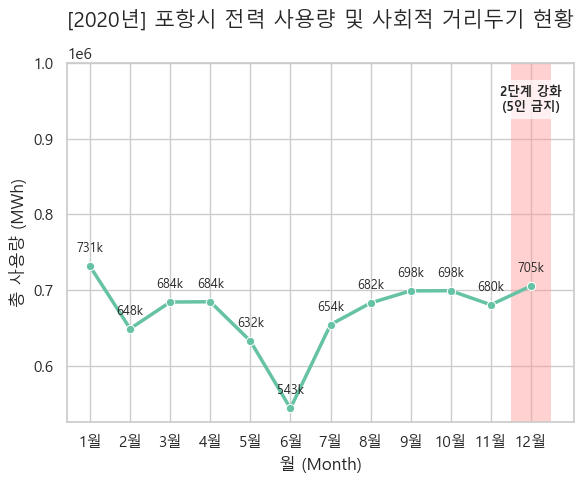

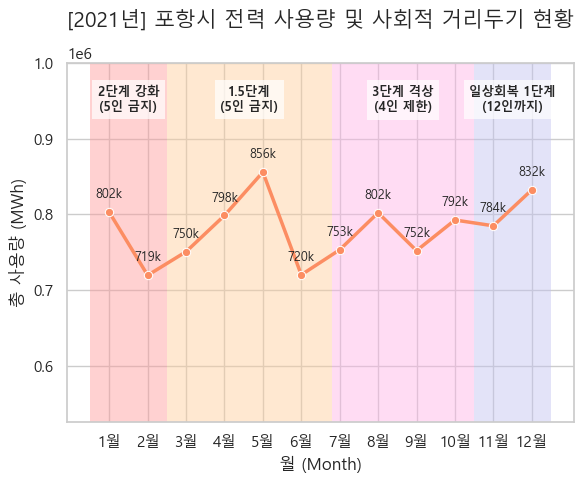

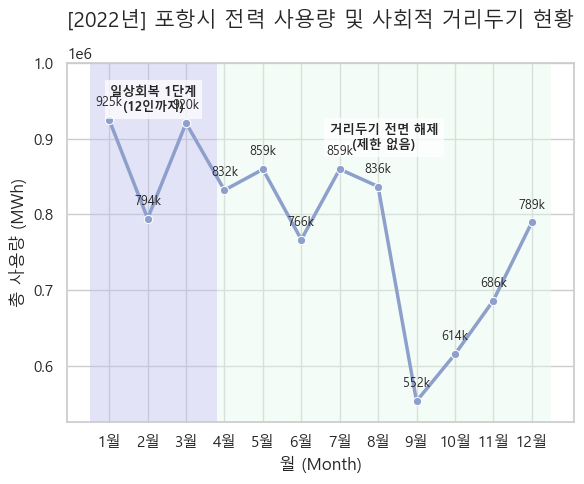

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

# 1. 환경 설정 및 데이터 로드
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font="Malgun Gothic")

df = pd.read_csv('포항시전력사용량_1923.csv') # 파일명 확인 필요

# 2. 색상 및 거리두기 기간 설정
COLOR_MAP = {
    'P1': ('#ff9999', '2단계 강화\n(5인 금지)'),
    'P2': ('#ffcc99', '1.5단계\n(5인 금지)'),
    'P3': ('#ffb3e6', '3단계 격상\n(4인 제한)'),
    'P4': ('#c2c2f0', '일상회복 1단계\n(12인까지)'),
    'P5': ('#e6f9ec', '거리두기 전면 해제\n(제한 없음)')
}

distancing_periods = {
    '2020': [(11.5, 12.5, 'P1')],
    '2021': [(0.5, 2.5, 'P1'), (2.5, 6.8, 'P2'), (6.8, 10.5, 'P3'), (10.5, 12.5, 'P4')],
    '2022': [(0.5, 3.8, 'P4'), (3.8, 12.5, 'P5')]
}

# 3. 연도별 개별 그래프 생성 루프
years = [2020, 2021, 2022]
line_colors = sns.color_palette("Set2", 3)

for i, year in enumerate(years):
    year_str = str(year)
    year_data = df[df['연도'] == year].sort_values('월')
    
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.set_ylim(525000, 1000000) # Y축 고정
    
    # 거리두기 배경색 칠하기
    if year_str in distancing_periods:
        for start, end, p_code in distancing_periods[year_str]:
            color, label = COLOR_MAP[p_code]
            ax.axvspan(start, end, color=color, alpha=0.45, lw=0)
            y_pos = 970000 if '해제' not in label else 920000
            ax.text((start+end)/2, y_pos, label, ha='center', va='top', 
                    fontsize=9, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    # 데이터 선 그래프
    sns.lineplot(x=year_data['월'], y=year_data['총사용량'], marker='o', ax=ax, color=line_colors[i], linewidth=2.5)
    
    # 그래프 꾸미기
    ax.set_title(f'[{year}년] 포항시 전력 사용량 및 사회적 거리두기 현황', fontsize=15, pad=15)
    ax.set_ylabel('총 사용량 (MWh)')
    ax.set_xlabel('월 (Month)')
    plt.xticks(range(1, 13), [f'{m}월' for m in range(1, 13)])
    
    # 수치 표시 (k 단위)
    for x, y in zip(year_data['월'], year_data['총사용량']):
        ax.annotate(f'{int(y/1000)}k', (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'pohang_electricity_{year}.png', dpi=300)
    plt.show()

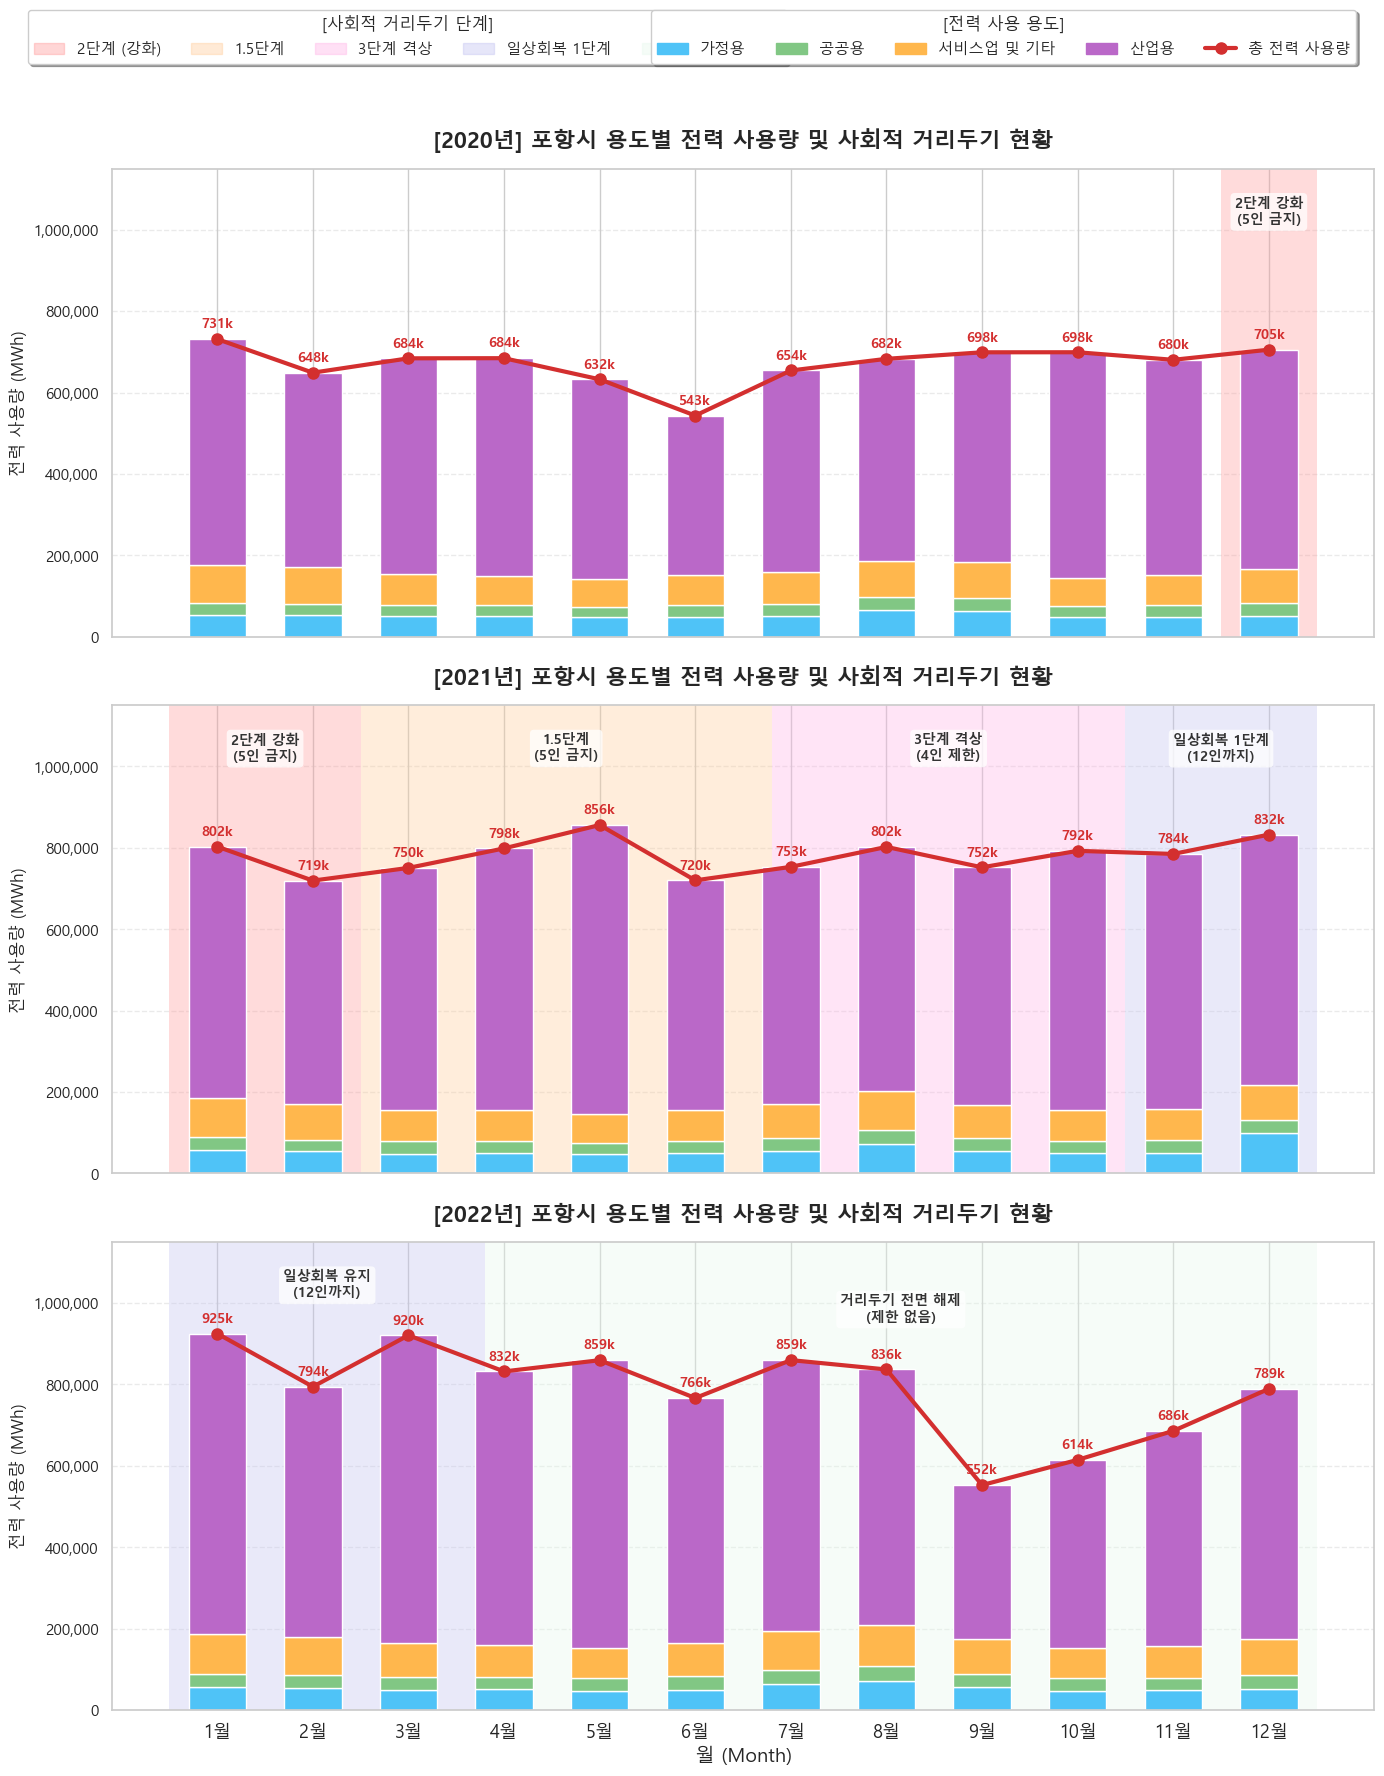

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

# 1. 폰트 및 시각화 환경 설정 (윈도우 맑은 고딕 기준)
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 2. 데이터 불러오기 (새로운 CSV 파일에 맞게 초간단 수정!)
try:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='cp949')

years = [2020, 2021, 2022]

# 범례에 표시될 이름과 실제 데이터베이스(CSV)의 컬럼명 매핑
categories_map = {
    '가정용': '가정용_사용량',
    '공공용': '공공용_사용량',
    '서비스업 및 기타': '서비스업_사용량',
    '산업용': '산업용_사용량'
}
category_labels = list(categories_map.keys())

# 3. 거리두기 표 기반 구간 및 색상 재설정
COLOR_P1 = '#ff9999' # 2단계 (강화)
COLOR_P2 = '#ffcc99' # 1.5단계
COLOR_P3 = '#ffb3e6' # 3단계
COLOR_P4 = '#c2c2f0' # 일상회복 1단계
COLOR_P5 = '#e6f9ec' # 거리두기 해제

# 새 데이터는 연도가 숫자로 들어있으므로 key 값을 정수(int)로 변경했습니다.
distancing_periods = {
    2020: [
        (11.5, 12.5, COLOR_P1, '2단계 강화\n(5인 금지)') 
    ],
    2021: [
        (0.5, 2.5, COLOR_P1, '2단계 강화\n(5인 금지)'),    
        (2.5, 6.8, COLOR_P2, '1.5단계\n(5인 금지)'),        
        (6.8, 10.5, COLOR_P3, '3단계 격상\n(4인 제한)'),      
        (10.5, 12.5, COLOR_P4, '일상회복 1단계\n(12인까지)') 
    ],
    2022: [
        (0.5, 3.8, COLOR_P4, '일상회복 유지\n(12인까지)'),    
        (3.8, 12.5, COLOR_P5, '거리두기 전면 해제\n(제한 없음)') 
    ]
}

# 4. 시각화 그리기
fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

# 누적 막대 그래프 색상 팔레트 (파랑, 초록, 주황, 보라)
bar_colors = ['#4fc3f7', '#81c784', '#ffb74d', '#ba68c8'] 

for i, year in enumerate(years):
    ax = axes[i]
    
    # 4-1. 해당 연도 데이터 추출 (df 필터링 방식)
    df_year = df[df['연도'] == year].sort_values('월').reset_index(drop=True)
    
    # ★ 핵심: Y축 범위 (막대그래프 왜곡 방지를 위해 0부터 시작, 115만까지 고정)
    ax.set_ylim(0, 1150000)
    
    # 4-2. 배경색 (axvspan) 및 라벨 달기
    if year in distancing_periods:
        for start, end, color, label in distancing_periods[year]:
            ax.axvspan(start, end, color=color, alpha=0.35, lw=0)
            
            y_pos = 1080000 if '해제' not in label else 1020000
            
            ax.text((start+end)/2, y_pos, label, 
                    ha='center', va='top', fontsize=10, fontweight='bold', color='#333333', 
                    bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.3'))

    # 4-3. 누적 막대그래프 (Stacked Bar) 그리기
    bottom = np.zeros(len(df_year['월']))
    for j, cat_label in enumerate(category_labels):
        col_name = categories_map[cat_label] # 실제 데이터 컬럼명 가져오기
        ax.bar(df_year['월'], df_year[col_name], bottom=bottom, color=bar_colors[j], edgecolor='white', width=0.6)
        bottom += df_year[col_name]

    # 4-4. 전체 사용량 선 그래프 (Line Plot) 그리기
    ax.plot(df_year['월'], df_year['총사용량'], marker='o', color='#d32f2f', linewidth=3, markersize=8)
    
    # 4-5. 그래프 꾸미기
    ax.set_title(f'[{year}년] 포항시 용도별 전력 사용량 및 사회적 거리두기 현황', fontsize=16, fontweight='bold', pad=15)
    ax.set_ylabel('전력 사용량 (MWh)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.4, axis='y')
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    
    # 총 사용량 수치 표시 (빨간 글씨)
    for x, y in zip(df_year['월'], df_year['총사용량']):
        ax.annotate(f'{int(y/1000)}k', (x, y), textcoords="offset points", xytext=(0,8), ha='center', fontsize=10, fontweight='bold', color='#d32f2f')

# ================= 범례(Legend) 설정 =================
# 좌측 상단: 거리두기 단계 범례
distancing_patches = [
    mpatches.Patch(color=COLOR_P1, alpha=0.4, label='2단계 (강화)'),
    mpatches.Patch(color=COLOR_P2, alpha=0.4, label='1.5단계'),
    mpatches.Patch(color=COLOR_P3, alpha=0.4, label='3단계 격상'),
    mpatches.Patch(color=COLOR_P4, alpha=0.4, label='일상회복 1단계'),
    mpatches.Patch(color=COLOR_P5, alpha=0.4, label='거리두기 해제')
]
fig.legend(handles=distancing_patches, loc='upper left', bbox_to_anchor=(0.02, 0.99), 
           ncol=5, fontsize=11, frameon=True, shadow=True, title="[사회적 거리두기 단계]")

# 우측 상단: 전력 사용 용도 범례
bar_patches = [mpatches.Patch(color=bar_colors[j], label=cat) for j, cat in enumerate(category_labels)]
bar_patches.append(plt.Line2D([0], [0], color='#d32f2f', marker='o', linewidth=3, markersize=8, label='총 전력 사용량'))
fig.legend(handles=bar_patches, loc='upper right', bbox_to_anchor=(0.98, 0.99), 
           ncol=5, fontsize=11, frameon=True, shadow=True, title="[전력 사용 용도]")
# ===================================================

plt.xticks(range(1, 13), [f'{m}월' for m in range(1, 13)], fontsize=13)
plt.xlabel('월 (Month)', fontsize=14)

# 전체 레이아웃 여백 조절
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

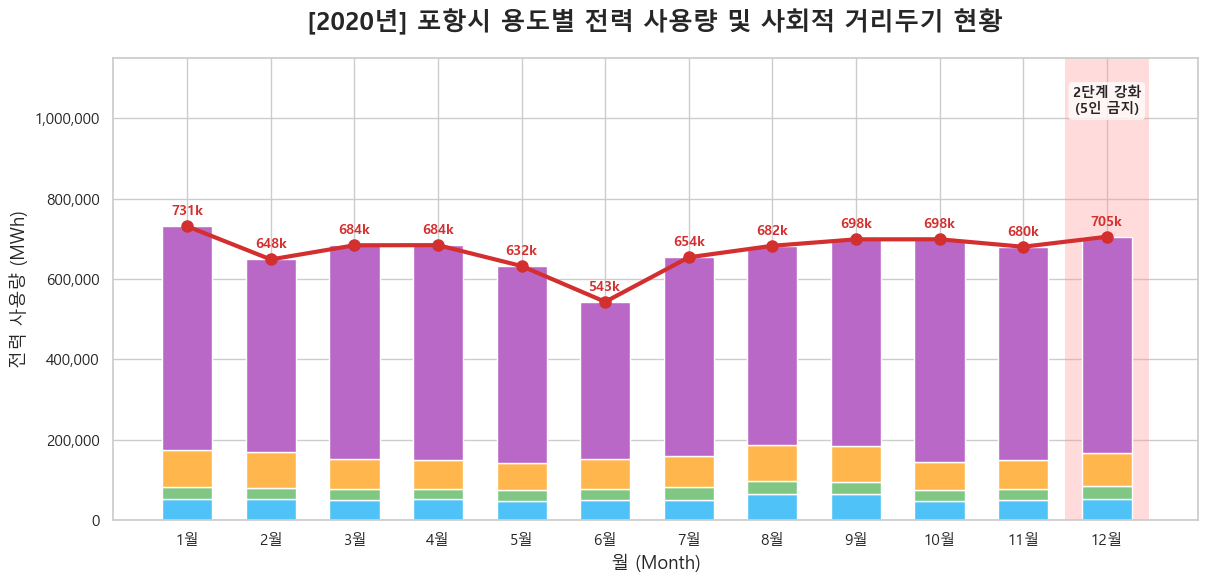

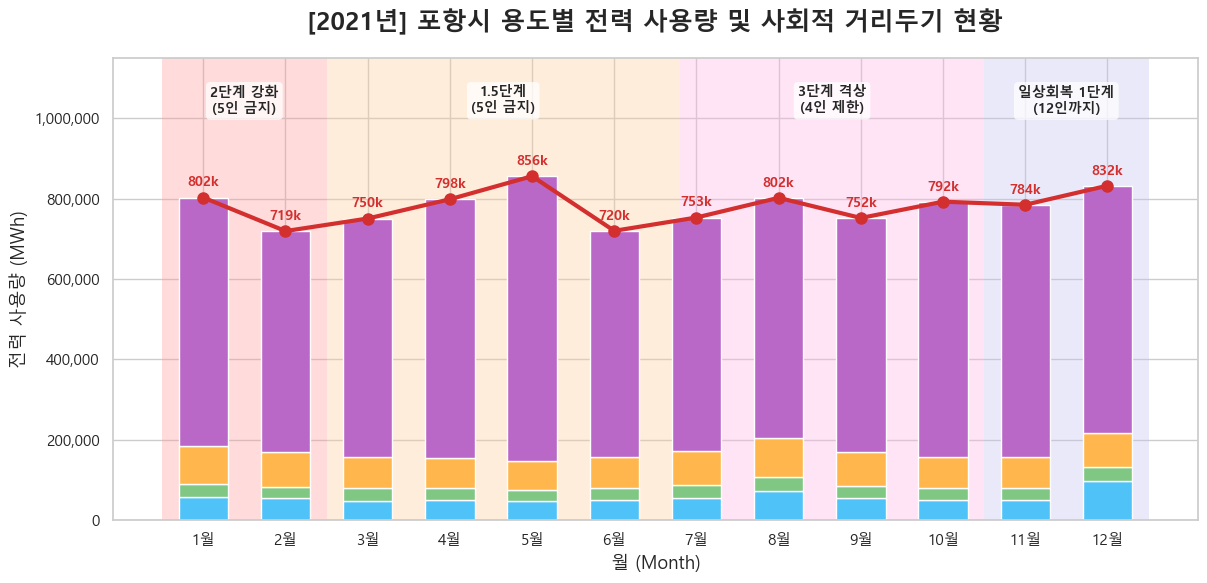

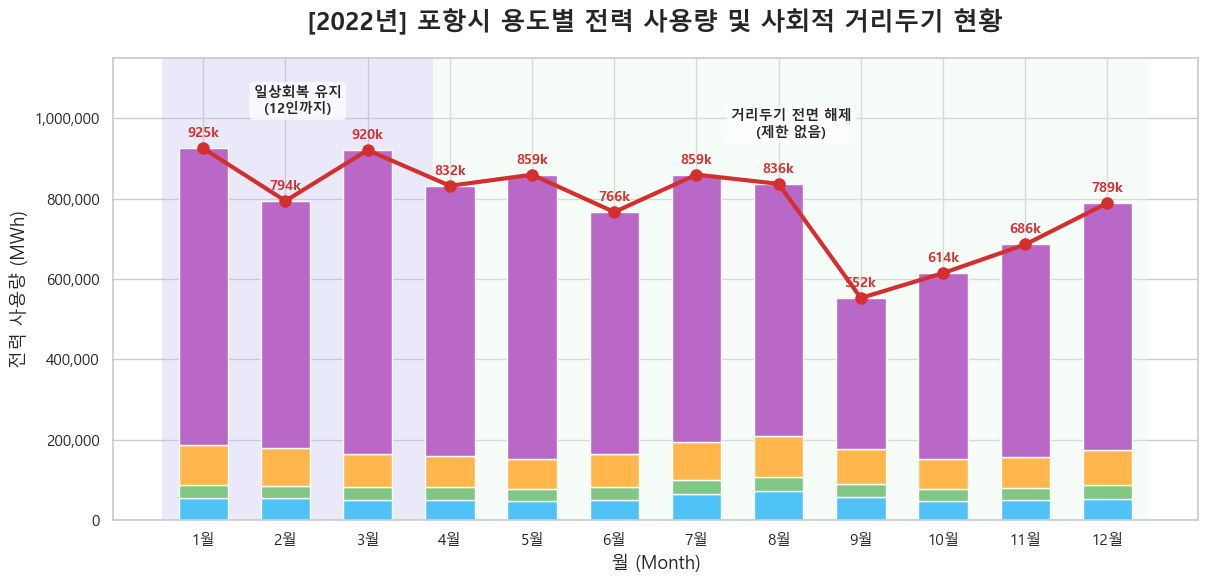

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

# 1. 폰트 및 시각화 환경 설정
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 2. 데이터 불러오기 (사용자 환경에 맞춰 파일명/인코딩 확인)
try:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='utf-8')
except:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='cp949')

years = [2020, 2021, 2022]
categories_map = {
    '가정용': '가정용_사용량',
    '공공용': '공공용_사용량',
    '서비스업': '서비스업_사용량', # CSV 컬럼명에 맞춰 수정 필요시 수정
    '산업용': '산업용_사용량'
}
category_labels = list(categories_map.keys())

# 3. 색상 및 거리두기 설정
COLOR_P1, COLOR_P2, COLOR_P3, COLOR_P4, COLOR_P5 = '#ff9999', '#ffcc99', '#ffb3e6', '#c2c2f0', '#e6f9ec'
bar_colors = ['#4fc3f7', '#81c784', '#ffb74d', '#ba68c8'] 

distancing_periods = {
    2020: [(11.5, 12.5, COLOR_P1, '2단계 강화\n(5인 금지)')],
    2021: [(0.5, 2.5, COLOR_P1, '2단계 강화\n(5인 금지)'), (2.5, 6.8, COLOR_P2, '1.5단계\n(5인 금지)'), 
           (6.8, 10.5, COLOR_P3, '3단계 격상\n(4인 제한)'), (10.5, 12.5, COLOR_P4, '일상회복 1단계\n(12인까지)')],
    2022: [(0.5, 3.8, COLOR_P4, '일상회복 유지\n(12인까지)'), (3.8, 12.5, COLOR_P5, '거리두기 전면 해제\n(제한 없음)')]
}

# 4. 루프를 돌며 개별 그래프 생성
for year in years:
    df_year = df[df['연도'] == year].sort_values('월').reset_index(drop=True)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.set_ylim(0, 1150000) # 모든 그래프의 Y축 눈금을 통일하여 비교 용이하게 설정
    
    # 4-1. 거리두기 배경색 및 텍스트
    if year in distancing_periods:
        for start, end, color, label in distancing_periods[year]:
            ax.axvspan(start, end, color=color, alpha=0.35, lw=0)
            y_pos = 1080000 if '해제' not in label else 1020000
            ax.text((start+end)/2, y_pos, label, ha='center', va='top', fontsize=10, 
                    fontweight='bold', bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.3'))

    # 4-2. 누적 막대그래프 (Stacked Bar)
    bottom = np.zeros(len(df_year['월']))
    for j, cat_label in enumerate(category_labels):
        col_name = categories_map[cat_label]
        ax.bar(df_year['월'], df_year[col_name], bottom=bottom, color=bar_colors[j], edgecolor='white', width=0.6, label=cat_label)
        bottom += df_year[col_name]

    # 4-3. 전체 사용량 선 그래프
    ax.plot(df_year['월'], df_year['총사용량'], marker='o', color='#d32f2f', linewidth=3, markersize=8, label='총 사용량')
    
    # 4-4. 그래프 디테일
    ax.set_title(f'[{year}년] 포항시 용도별 전력 사용량 및 사회적 거리두기 현황', fontsize=18, fontweight='bold', pad=20)
    ax.set_ylabel('전력 사용량 (MWh)', fontsize=13)
    ax.set_xlabel('월 (Month)', fontsize=13)
    plt.xticks(range(1, 13), [f'{m}월' for m in range(1, 13)], fontsize=11)
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    
    # 수치 표시
    for x, y in zip(df_year['월'], df_year['총사용량']):
        ax.annotate(f'{int(y/1000)}k', (x, y), textcoords="offset points", xytext=(0,8), 
                    ha='center', fontsize=10, fontweight='bold', color='#d32f2f')

    # 4-5. 범례 통합 설정
    # 하단에 범례를 배치하여 PPT 슬라이드 공간 활용도 높임
    handles, labels = ax.get_legend_handles_labels()
    
    # 거리두기 범례 조각들 수동 생성
    dist_legend = [mpatches.Patch(color=c, alpha=0.4, label=l) for c, l in [
        (COLOR_P1, '2단계(강화)'), (COLOR_P2, '1.5단계'), (COLOR_P3, '3단계격상'), (COLOR_P4, '일상회복'), (COLOR_P5, '거리두기해제')
    ]]
    

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_15100\1464197271.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_totals, x='용도', y='총사용량', palette=custom_palette)


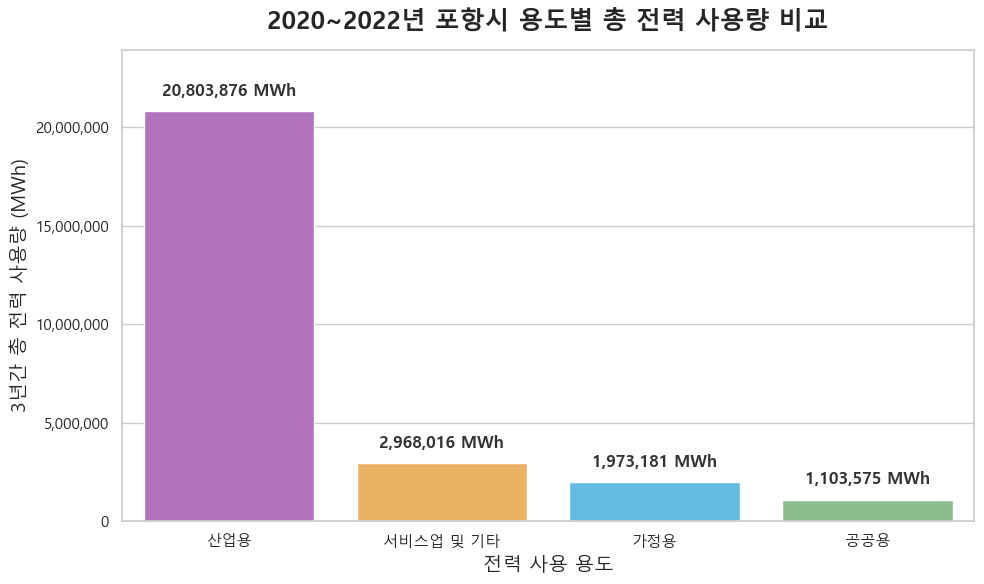

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 폰트 및 시각화 환경 설정 (윈도우 맑은 고딕 기준)
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 2. 데이터 불러오기
try:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='cp949')

# 3. 2020~2022년 핵심 데이터만 필터링
df_filtered = df[df['연도'].isin([2020, 2021, 2022])]

# 4. 3년간 용도별 총사용량 계산
category_totals = {
    '가정용': df_filtered['가정용_사용량'].sum(),
    '공공용': df_filtered['공공용_사용량'].sum(),
    '서비스업 및 기타': df_filtered['서비스업_사용량'].sum(),
    '산업용': df_filtered['산업용_사용량'].sum()
}

# 5. DataFrame으로 변환 후 내림차순 정렬
df_totals = pd.DataFrame(list(category_totals.items()), columns=['용도', '총사용량'])
df_totals = df_totals.sort_values(by='총사용량', ascending=False)

# ★ 6. 핵심 수정: 이전 그래프들과 동일한 컬러 매핑 딕셔너리 생성
custom_palette = {
    '산업용': '#ba68c8',         # 보라색
    '서비스업 및 기타': '#ffb74d', # 노란/주황색
    '가정용': '#4fc3f7',         # 파란색
    '공공용': '#81c784'          # 초록색
}

# 7. 시각화 그리기
plt.figure(figsize=(10, 6))

# palette에 커스텀 색상을 지정하여 막대그래프 생성
ax = sns.barplot(data=df_totals, x='용도', y='총사용량', palette=custom_palette)

# 8. 그래프 꾸미기
plt.title('2020~2022년 포항시 용도별 총 전력 사용량 비교', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('전력 사용 용도', fontsize=14)
plt.ylabel('3년간 총 전력 사용량 (MWh)', fontsize=14)

# Y축 콤마 포맷팅
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 막대 위에 수치 라벨 추가
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,} MWh', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                xytext=(0, 8), textcoords='offset points',
                fontsize=12, fontweight='bold', color='#333333')

# Y축 상단 여백 추가 (라벨 잘림 방지)
plt.ylim(0, df_totals['총사용량'].max() * 1.15)

plt.tight_layout()
plt.show()

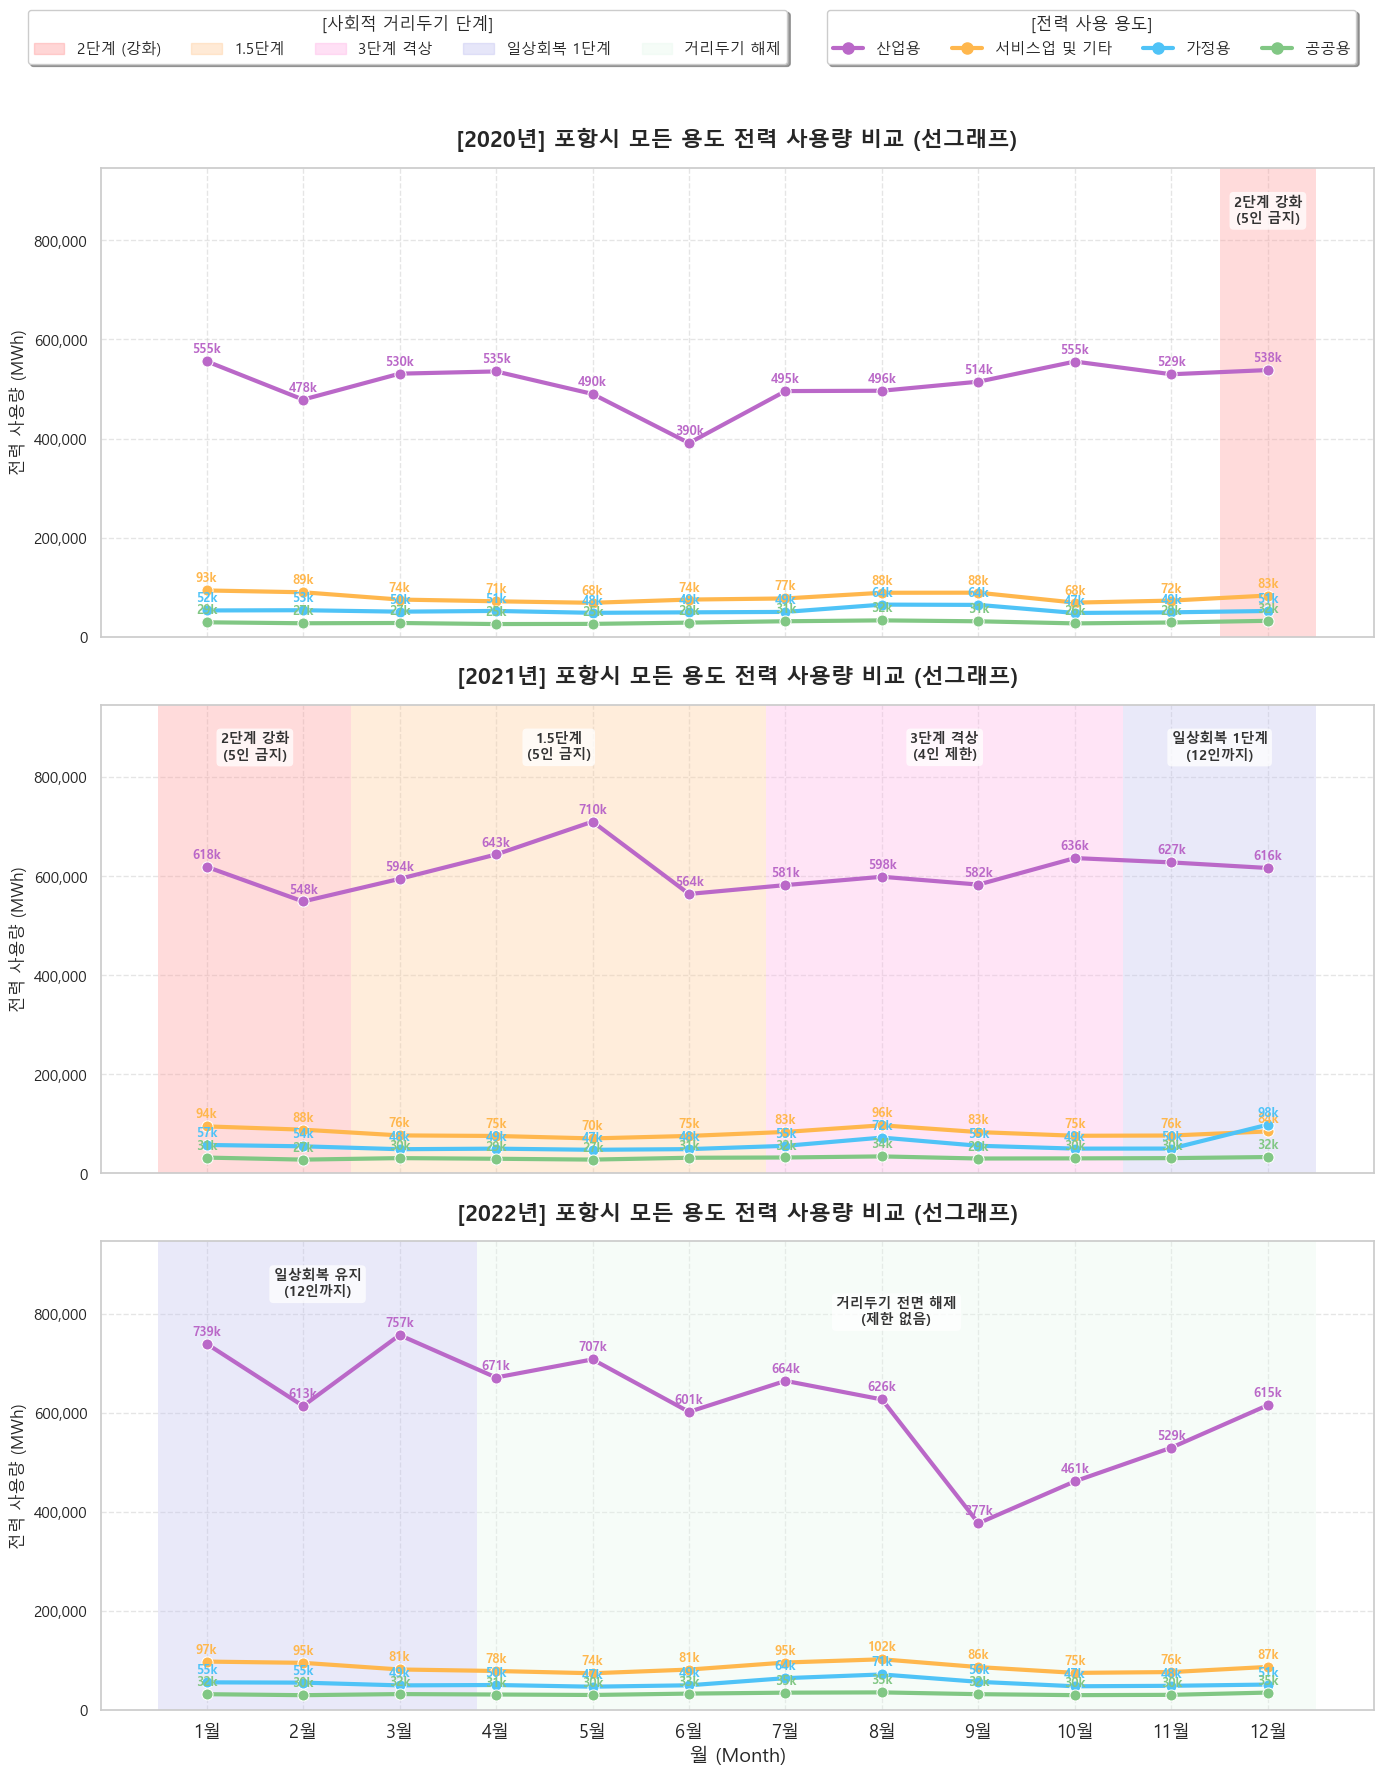

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

# 1. 폰트 및 시각화 환경 설정 (윈도우 맑은 고딕 기준)
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 2. 데이터 불러오기 (새로운 CSV 파일)
try:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='cp949')

years = [2020, 2021, 2022]

# 컬러 매핑 및 컬럼 연결 (기존 테마 유지)
line_colors = {
    '산업용': '#ba68c8',        # 보라색
    '서비스업 및 기타': '#ffb74d',  # 주황색
    '가정용': '#4fc3f7',        # 파란색
    '공공용': '#81c784'         # 초록색
}

col_mapping = {
    '산업용': '산업용_사용량',
    '서비스업 및 기타': '서비스업_사용량',
    '가정용': '가정용_사용량',
    '공공용': '공공용_사용량'
}

# 3. Y축 범위 계산 (4개 선이 모두 나오도록 바닥(0)부터 천장(최대값의 1.25배)까지 설정)
max_val = df[df['연도'].isin(years)][list(col_mapping.values())].max().max()
y_min = 0 
y_max = max_val * 1.25 # 상단 배경색 라벨 여백 확보

# 4. 거리두기 표 기반 구간 및 색상 재설정
COLOR_P1 = '#ff9999' # 2단계 (강화)
COLOR_P2 = '#ffcc99' # 1.5단계
COLOR_P3 = '#ffb3e6' # 3단계
COLOR_P4 = '#c2c2f0' # 일상회복 1단계
COLOR_P5 = '#e6f9ec' # 거리두기 해제

distancing_periods = {
    2020: [(11.5, 12.5, COLOR_P1, '2단계 강화\n(5인 금지)')],
    2021: [
        (0.5, 2.5, COLOR_P1, '2단계 강화\n(5인 금지)'),    
        (2.5, 6.8, COLOR_P2, '1.5단계\n(5인 금지)'),        
        (6.8, 10.5, COLOR_P3, '3단계 격상\n(4인 제한)'),      
        (10.5, 12.5, COLOR_P4, '일상회복 1단계\n(12인까지)') 
    ],
    2022: [
        (0.5, 3.8, COLOR_P4, '일상회복 유지\n(12인까지)'),    
        (3.8, 12.5, COLOR_P5, '거리두기 전면 해제\n(제한 없음)') 
    ]
}

# 5. 시각화 그리기 (14x18 사이즈로 시원하게 배치)
fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

for i, year in enumerate(years):
    ax = axes[i]
    df_year = df[df['연도'] == year].sort_values('월').reset_index(drop=True)
    
    # Y축 고정 (0부터 약 89만까지)
    ax.set_ylim(y_min, y_max)
    
    # 배경색 (axvspan) 및 라벨 달기
    if year in distancing_periods:
        for start, end, color, label in distancing_periods[year]:
            ax.axvspan(start, end, color=color, alpha=0.35, lw=0)
            
            y_pos = y_max * 0.94 if '해제' not in label else y_max * 0.88
            
            ax.text((start+end)/2, y_pos, label, 
                    ha='center', va='top', fontsize=10, fontweight='bold', color='#333333', 
                    bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.3'))

    # ★ 4개의 선을 하나의 도화지(ax)에 반복해서 그리기
    for cat_name, col_name in col_mapping.items():
        c = line_colors[cat_name]
        
        # 선 그리기
        sns.lineplot(data=df_year, x='월', y=col_name, marker='o', ax=ax, color=c, linewidth=3, markersize=8)
        
        # 데이터 라벨 (k 단위 축약 표시)
        for x, y in zip(df_year['월'], df_year[col_name]):
            ax.annotate(f'{int(y/1000)}k', (x, y), textcoords="offset points", xytext=(0,6), ha='center', fontsize=9, color=c, fontweight='bold')

    # 그래프 꾸미기
    ax.set_title(f'[{year}년] 포항시 모든 용도 전력 사용량 비교 (선그래프)', fontsize=16, fontweight='bold', pad=15)
    ax.set_ylabel('전력 사용량 (MWh)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# ================= 상단 범례(Legend) 설정 =================
# 좌측: 거리두기 단계 범례
distancing_patches = [
    mpatches.Patch(color=COLOR_P1, alpha=0.4, label='2단계 (강화)'),
    mpatches.Patch(color=COLOR_P2, alpha=0.4, label='1.5단계'),
    mpatches.Patch(color=COLOR_P3, alpha=0.4, label='3단계 격상'),
    mpatches.Patch(color=COLOR_P4, alpha=0.4, label='일상회복 1단계'),
    mpatches.Patch(color=COLOR_P5, alpha=0.4, label='거리두기 해제')
]
fig.legend(handles=distancing_patches, loc='upper left', bbox_to_anchor=(0.02, 0.99), 
           ncol=5, fontsize=11, frameon=True, shadow=True, title="[사회적 거리두기 단계]")

# 우측: 전력 용도 범례
line_patches = [plt.Line2D([0], [0], color=line_colors[cat], marker='o', linewidth=3, markersize=8, label=cat) for cat in col_mapping.keys()]
fig.legend(handles=line_patches, loc='upper right', bbox_to_anchor=(0.98, 0.99), 
           ncol=4, fontsize=11, frameon=True, shadow=True, title="[전력 사용 용도]")
# =======================================================

# 축 세팅
plt.xticks(range(1, 13), [f'{m}월' for m in range(1, 13)], fontsize=13)
plt.xlabel('월 (Month)', fontsize=14)

# 전체 레이아웃 (범례 공간 확보)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

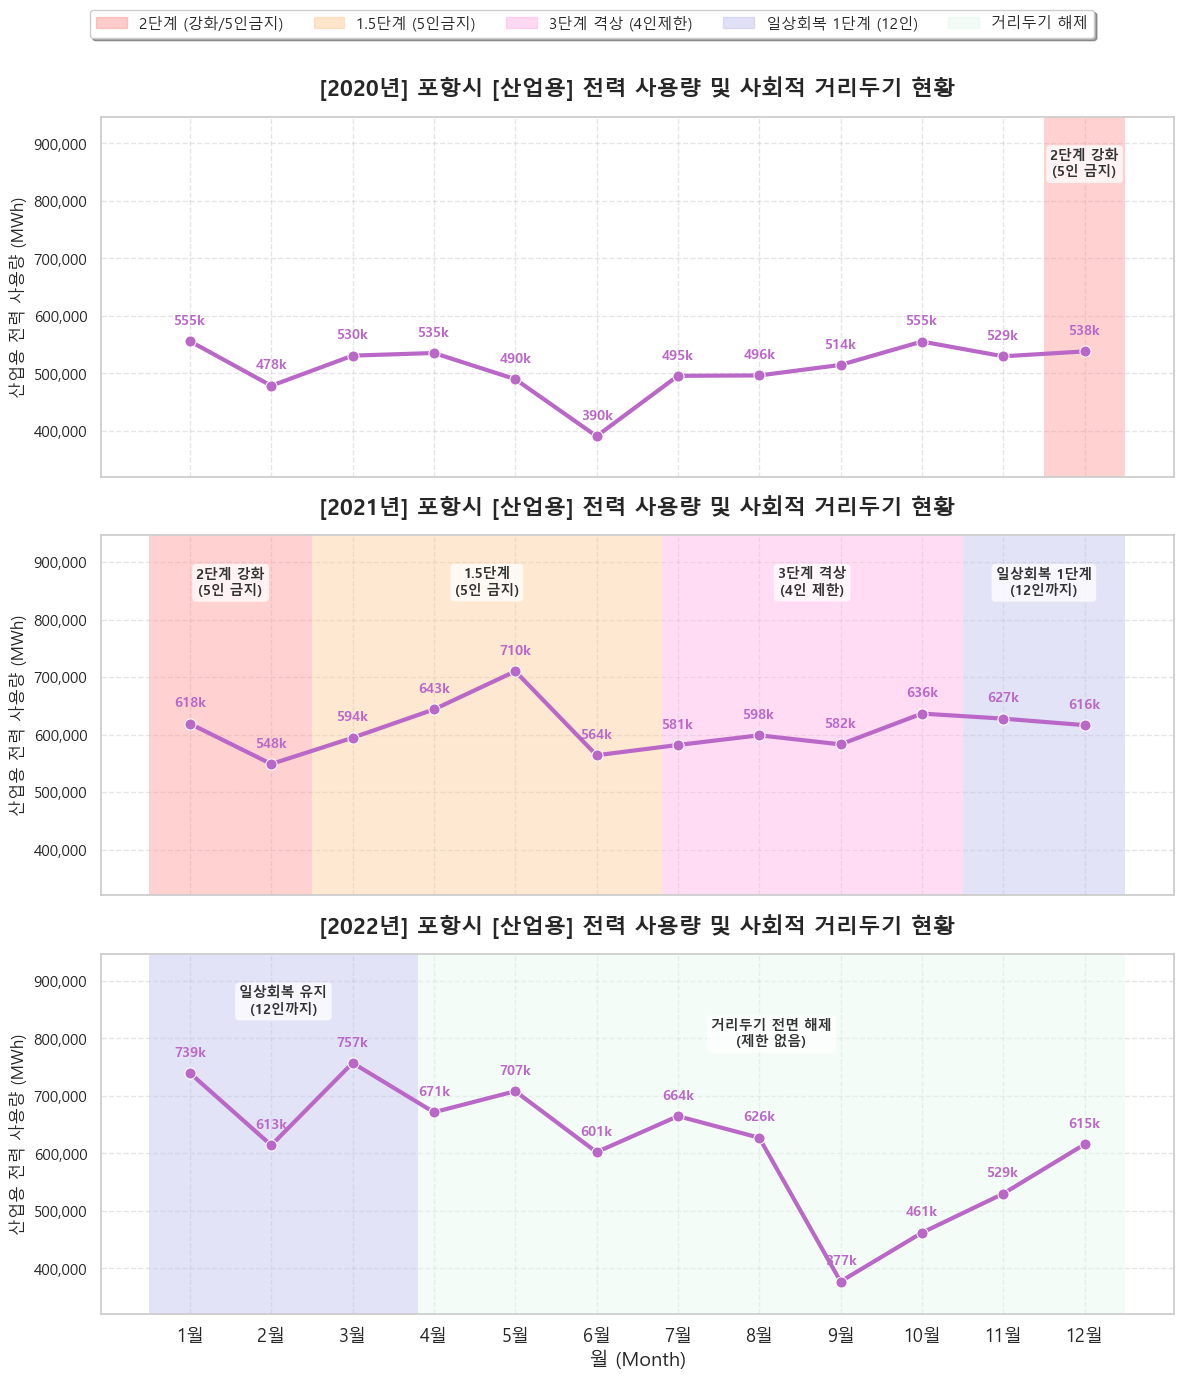

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

# 1. 폰트 및 시각화 환경 설정 (윈도우 맑은 고딕 기준)
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 2. 데이터 불러오기 및 전처리 (새로운 CSV 파일에 맞게 수정!)
try:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='cp949')

years = [2020, 2021, 2022]

# ★ 핵심 수정 파트: 새 파일에서 '산업용' 데이터만 추출
ind_usage = pd.DataFrame({'월': range(1, 13)})
for year in years:
    year_data = df[df['연도'] == year].sort_values('월')
    ind_usage[str(year)] = year_data['산업용_사용량'].values

# 3. Y축 범위 자동 조정 세팅 (산업용 스케일에 맞춤)
max_val = ind_usage[[str(y) for y in years]].max().max()
min_val = ind_usage[[str(y) for y in years]].min().min()

# 하한선을 실제 데이터의 최소값보다 15% 낮게 설정 (바닥 뚫림 방지)
y_min = min_val * 0.85 
y_max = max_val * 1.25 # 상단 배경색 라벨 여백 확보

# 4. 거리두기 표 기반 구간 및 색상 재설정
COLOR_P1 = '#ff9999' # 2단계 (강화)
COLOR_P2 = '#ffcc99' # 1.5단계
COLOR_P3 = '#ffb3e6' # 3단계
COLOR_P4 = '#c2c2f0' # 일상회복 1단계
COLOR_P5 = '#e6f9ec' # 거리두기 해제

distancing_periods = {
    '2020': [
        (11.5, 12.5, COLOR_P1, '2단계 강화\n(5인 금지)') 
    ],
    '2021': [
        (0.5, 2.5, COLOR_P1, '2단계 강화\n(5인 금지)'),    
        (2.5, 6.8, COLOR_P2, '1.5단계\n(5인 금지)'),        
        (6.8, 10.5, COLOR_P3, '3단계 격상\n(4인 제한)'),      
        (10.5, 12.5, COLOR_P4, '일상회복 1단계\n(12인까지)') 
    ],
    '2022': [
        (0.5, 3.8, COLOR_P4, '일상회복 유지\n(12인까지)'),    
        (3.8, 12.5, COLOR_P5, '거리두기 전면 해제\n(제한 없음)') 
    ]
}

# 5. 시각화 그리기
fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)
ind_color = '#ba68c8' # 산업용 테마 컬러 (보라색)

for i, year in enumerate([str(y) for y in years]):
    ax = axes[i]
    
    # Y축 고정
    ax.set_ylim(y_min, y_max)
    
    # 배경색 (axvspan) 및 라벨 달기
    if year in distancing_periods:
        for start, end, color, label in distancing_periods[year]:
            ax.axvspan(start, end, color=color, alpha=0.45, lw=0)
            
            y_pos = y_max * 0.94 if '해제' not in label else y_max * 0.88
            
            ax.text((start+end)/2, y_pos, label, 
                    ha='center', va='top', fontsize=10, fontweight='bold', color='#333333', 
                    bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.3'))

    # 산업용 전력 선 그래프
    sns.lineplot(data=ind_usage, x='월', y=year, marker='o', ax=ax, color=ind_color, linewidth=3, markersize=8)
    
    ax.set_title(f'[{year}년] 포항시 [산업용] 전력 사용량 및 사회적 거리두기 현황', fontsize=16, fontweight='bold', pad=15)
    ax.set_ylabel('산업용 전력 사용량 (MWh)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    
    # 데이터 라벨 달기 (글씨 색상 통일)
    for x, y in zip(ind_usage['월'], ind_usage[year]):
        ax.annotate(f'{int(y/1000)}k', (x, y), textcoords="offset points", xytext=(0,12), ha='center', fontsize=10, color=ind_color, fontweight='bold')

# 범례(Legend) 붙이기
legend_patches = [
    mpatches.Patch(color=COLOR_P1, alpha=0.5, label='2단계 (강화/5인금지)'),
    mpatches.Patch(color=COLOR_P2, alpha=0.5, label='1.5단계 (5인금지)'),
    mpatches.Patch(color=COLOR_P3, alpha=0.5, label='3단계 격상 (4인제한)'),
    mpatches.Patch(color=COLOR_P4, alpha=0.5, label='일상회복 1단계 (12인)'),
    mpatches.Patch(color=COLOR_P5, alpha=0.5, label='거리두기 해제')
]
fig.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, 0.99), 
           ncol=5, fontsize=11, frameon=True, shadow=True)

# 축 세팅
plt.xticks(range(1, 13), [f'{m}월' for m in range(1, 13)], fontsize=13)
plt.xlabel('월 (Month)', fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

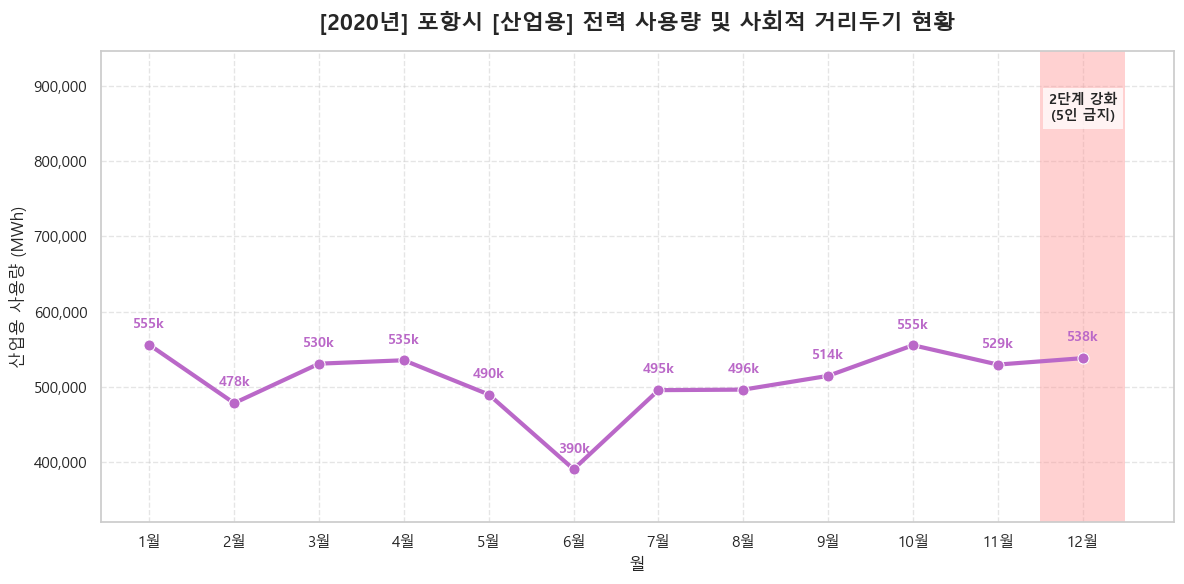

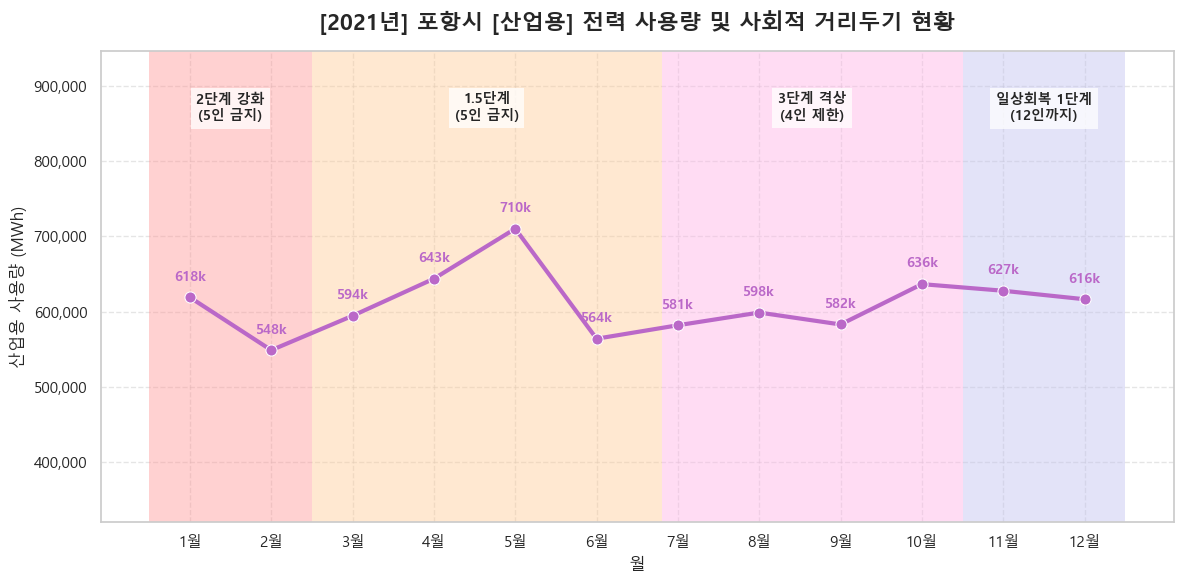

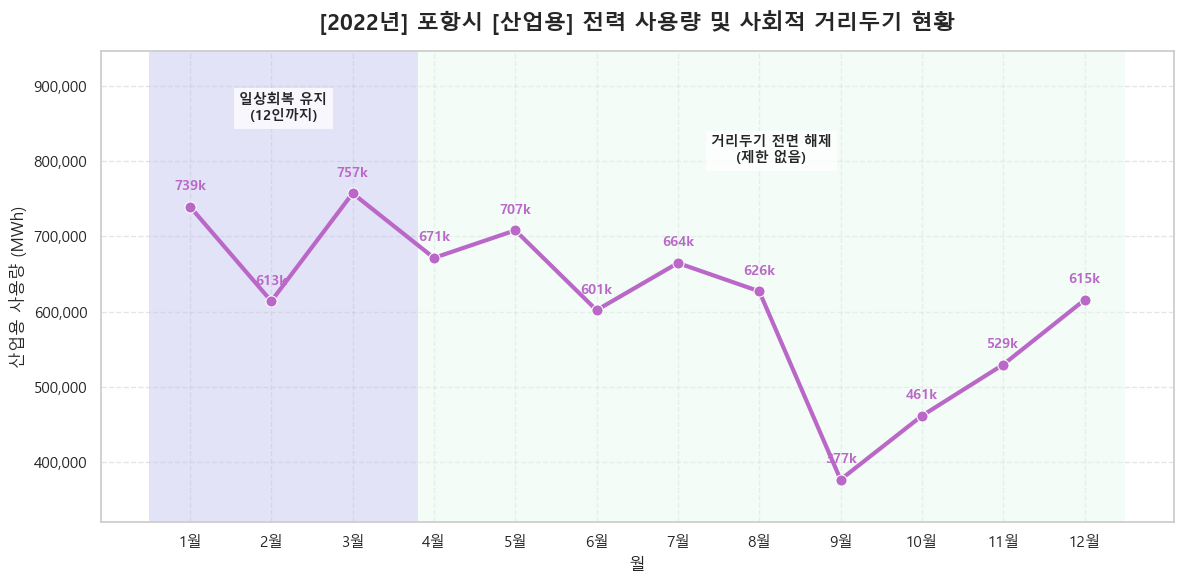

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

# 1. 폰트 및 시각화 환경 설정
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 2. 데이터 불러오기 및 전처리
try:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='cp949')

years = [2020, 2021, 2022]

# 산업용 데이터만 별도 추출
ind_usage = pd.DataFrame({'월': range(1, 13)})
for year in years:
    year_data = df[df['연도'] == year].sort_values('월')
    ind_usage[str(year)] = year_data['산업용_사용량'].values

# 3. Y축 범위 자동 고정 (모든 그래프의 스케일을 통일하기 위함)
max_val = ind_usage[[str(y) for y in years]].max().max()
min_val = ind_usage[[str(y) for y in years]].min().min()
y_min = min_val * 0.85 
y_max = max_val * 1.25 # 상단 라벨 공간 확보

# 4. 거리두기 설정
COLOR_P1, COLOR_P2, COLOR_P3, COLOR_P4, COLOR_P5 = '#ff9999', '#ffcc99', '#ffb3e6', '#c2c2f0', '#e6f9ec'
distancing_periods = {
    '2020': [(11.5, 12.5, COLOR_P1, '2단계 강화\n(5인 금지)')],
    '2021': [
        (0.5, 2.5, COLOR_P1, '2단계 강화\n(5인 금지)'),
        (2.5, 6.8, COLOR_P2, '1.5단계\n(5인 금지)'),
        (6.8, 10.5, COLOR_P3, '3단계 격상\n(4인 제한)'),
        (10.5, 12.5, COLOR_P4, '일상회복 1단계\n(12인까지)')
    ],
    '2022': [
        (0.5, 3.8, COLOR_P4, '일상회복 유지\n(12인까지)'),
        (3.8, 12.5, COLOR_P5, '거리두기 전면 해제\n(제한 없음)')
    ]
}

# 5. 연도별 개별 그래프 생성 루프
ind_color = '#ba68c8' # 산업용 테마 컬러

for year_str in [str(y) for y in years]:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Y축 범위 고정
    ax.set_ylim(y_min, y_max)
    
    # 거리두기 배경색 및 라벨
    if year_str in distancing_periods:
        for start, end, color, label in distancing_periods[year_str]:
            ax.axvspan(start, end, color=color, alpha=0.45, lw=0)
            # 텍스트 위치 자동 조정
            y_pos = y_max * 0.94 if '해제' not in label else y_max * 0.88
            ax.text((start+end)/2, y_pos, label, ha='center', va='top', fontsize=10, 
                    fontweight='bold', bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))

    # 산업용 전력 선 그래프 그리기
    sns.lineplot(x=ind_usage['월'], y=ind_usage[year_str], marker='o', ax=ax, color=ind_color, linewidth=3, markersize=8)
    
    # 그래프 꾸미기
    ax.set_title(f'[{year_str}년] 포항시 [산업용] 전력 사용량 및 사회적 거리두기 현황', fontsize=16, fontweight='bold', pad=15)
    ax.set_ylabel('산업용 사용량 (MWh)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    
    # 수치 표시
    for x, y in zip(ind_usage['월'], ind_usage[year_str]):
        ax.annotate(f'{int(y/1000)}k', (x, y), textcoords="offset points", xytext=(0,12), 
                    ha='center', fontsize=10, color=ind_color, fontweight='bold')

    plt.xticks(range(1, 13), [f'{m}월' for m in range(1, 13)], fontsize=11)
    plt.tight_layout()
    
    # 파일 저장 (PPT 삽입용)
    plt.savefig(f'pohang_industrial_{year_str}.png', dpi=300)
    plt.show()

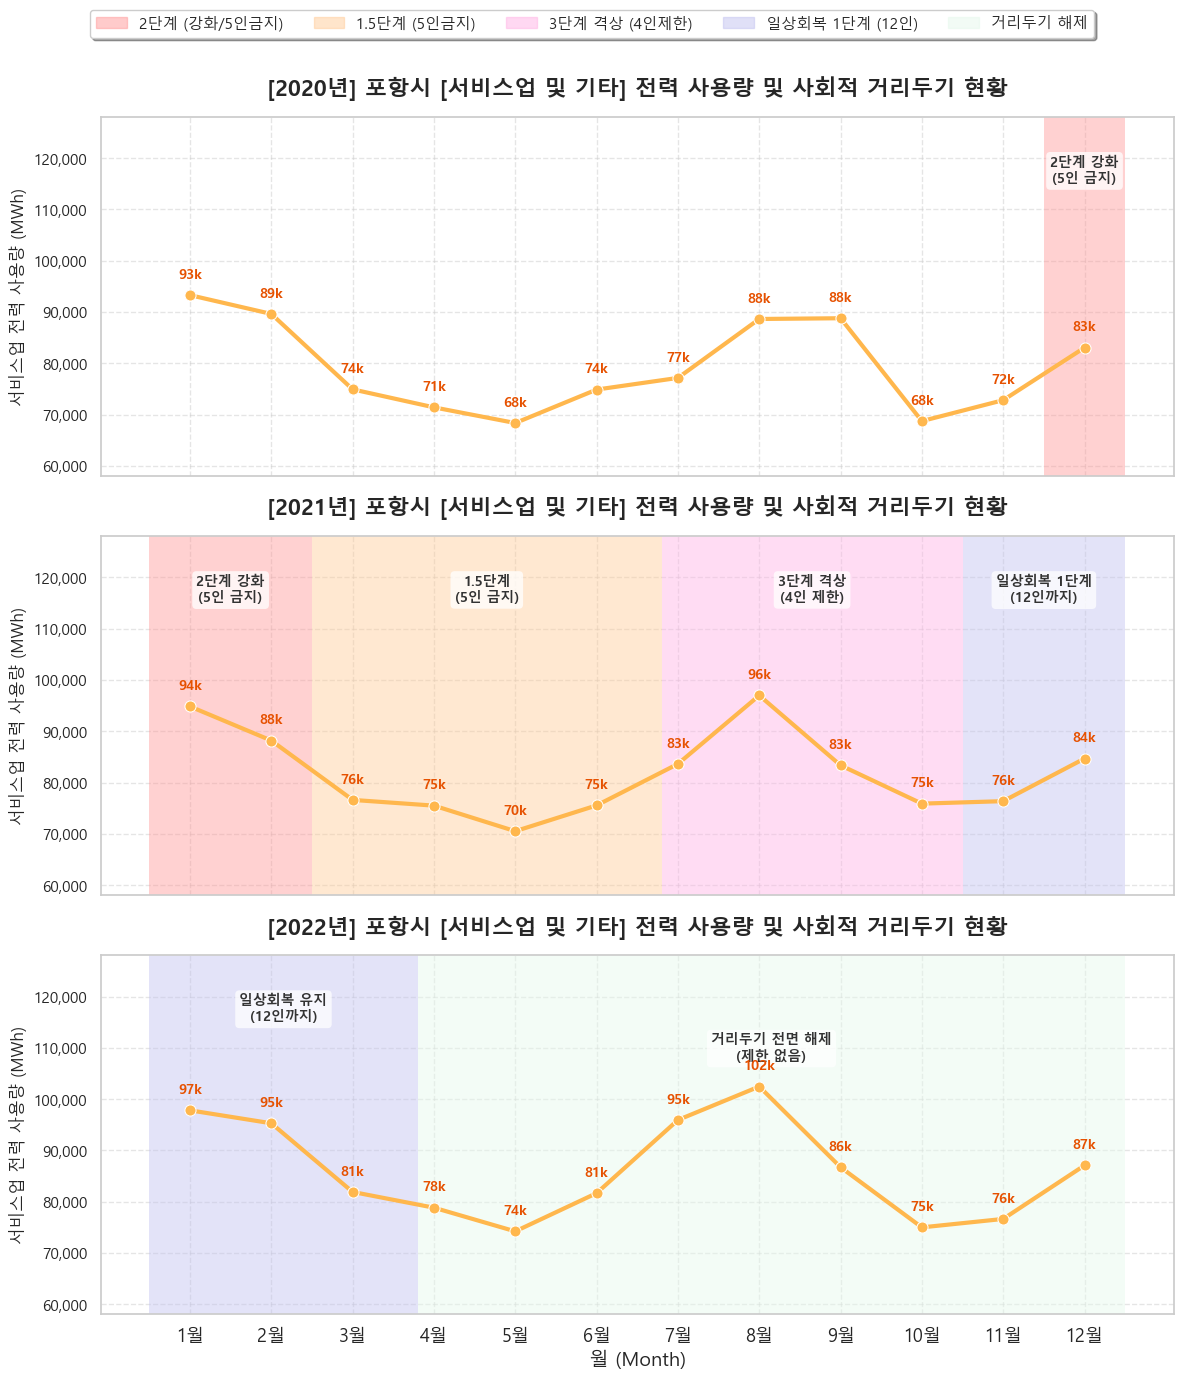

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

# 1. 폰트 및 시각화 환경 설정
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 2. 데이터 불러오기 및 전처리 (새로운 CSV 파일에 맞게 수정!)
try:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='cp949')

years = [2020, 2021, 2022]

# ★ 핵심: 새 파일에서 '서비스업_사용량' 데이터만 추출
service_usage = pd.DataFrame({'월': range(1, 13)})
for year in years:
    year_data = df[df['연도'] == year].sort_values('월')
    service_usage[str(year)] = year_data['서비스업_사용량'].values

# 3. ★ 핵심 수정 파트: Y축 범위 자동 조정 (바닥 뚫림 방지) ★
max_val = service_usage[[str(y) for y in years]].max().max()
min_val = service_usage[[str(y) for y in years]].min().min()

# 하한선을 실제 데이터의 최소값보다 15% 낮게 설정하여 선이 뚫고 나가지 않게 조치
y_min = min_val * 0.85 
y_max = max_val * 1.25 # 상단 배경색 라벨 여백 확보

# 4. 거리두기 표 기반 구간 및 색상 재설정
COLOR_P1 = '#ff9999' # 2단계 (강화)
COLOR_P2 = '#ffcc99' # 1.5단계
COLOR_P3 = '#ffb3e6' # 3단계
COLOR_P4 = '#c2c2f0' # 일상회복 1단계
COLOR_P5 = '#e6f9ec' # 거리두기 해제

distancing_periods = {
    '2020': [
        (11.5, 12.5, COLOR_P1, '2단계 강화\n(5인 금지)') 
    ],
    '2021': [
        (0.5, 2.5, COLOR_P1, '2단계 강화\n(5인 금지)'),    
        (2.5, 6.8, COLOR_P2, '1.5단계\n(5인 금지)'),        
        (6.8, 10.5, COLOR_P3, '3단계 격상\n(4인 제한)'),      
        (10.5, 12.5, COLOR_P4, '일상회복 1단계\n(12인까지)') 
    ],
    '2022': [
        (0.5, 3.8, COLOR_P4, '일상회복 유지\n(12인까지)'),    
        (3.8, 12.5, COLOR_P5, '거리두기 전면 해제\n(제한 없음)') 
    ]
}

# 5. 시각화 그리기
fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)
service_color = '#ffb74d' # 서비스업 테마 컬러 (주황색)

for i, year in enumerate([str(y) for y in years]):
    ax = axes[i]
    
    # 수정된 Y축 고정값 적용
    ax.set_ylim(y_min, y_max)
    
    # 배경색 (axvspan) 및 라벨 달기
    if year in distancing_periods:
        for start, end, color, label in distancing_periods[year]:
            ax.axvspan(start, end, color=color, alpha=0.45, lw=0)
            
            y_pos = y_max * 0.94 if '해제' not in label else y_max * 0.88
            
            ax.text((start+end)/2, y_pos, label, 
                    ha='center', va='top', fontsize=10, fontweight='bold', color='#333333', 
                    bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.3'))

    # 서비스업 전력 선 그래프
    sns.lineplot(data=service_usage, x='월', y=str(year), marker='o', ax=ax, color=service_color, linewidth=3, markersize=8)
    
    ax.set_title(f'[{year}년] 포항시 [서비스업 및 기타] 전력 사용량 및 사회적 거리두기 현황', fontsize=16, fontweight='bold', pad=15)
    ax.set_ylabel('서비스업 전력 사용량 (MWh)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    
    # 데이터 라벨 달기
    for x, y in zip(service_usage['월'], service_usage[str(year)]):
        ax.annotate(f'{int(y/1000)}k', (x, y), textcoords="offset points", xytext=(0,12), ha='center', fontsize=10, color='#e65100', fontweight='bold')

# 범례(Legend) 붙이기
legend_patches = [
    mpatches.Patch(color=COLOR_P1, alpha=0.5, label='2단계 (강화/5인금지)'),
    mpatches.Patch(color=COLOR_P2, alpha=0.5, label='1.5단계 (5인금지)'),
    mpatches.Patch(color=COLOR_P3, alpha=0.5, label='3단계 격상 (4인제한)'),
    mpatches.Patch(color=COLOR_P4, alpha=0.5, label='일상회복 1단계 (12인)'),
    mpatches.Patch(color=COLOR_P5, alpha=0.5, label='거리두기 해제')
]
fig.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, 0.99), 
           ncol=5, fontsize=11, frameon=True, shadow=True)

# 축 세팅
plt.xticks(range(1, 13), [f'{m}월' for m in range(1, 13)], fontsize=13)
plt.xlabel('월 (Month)', fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

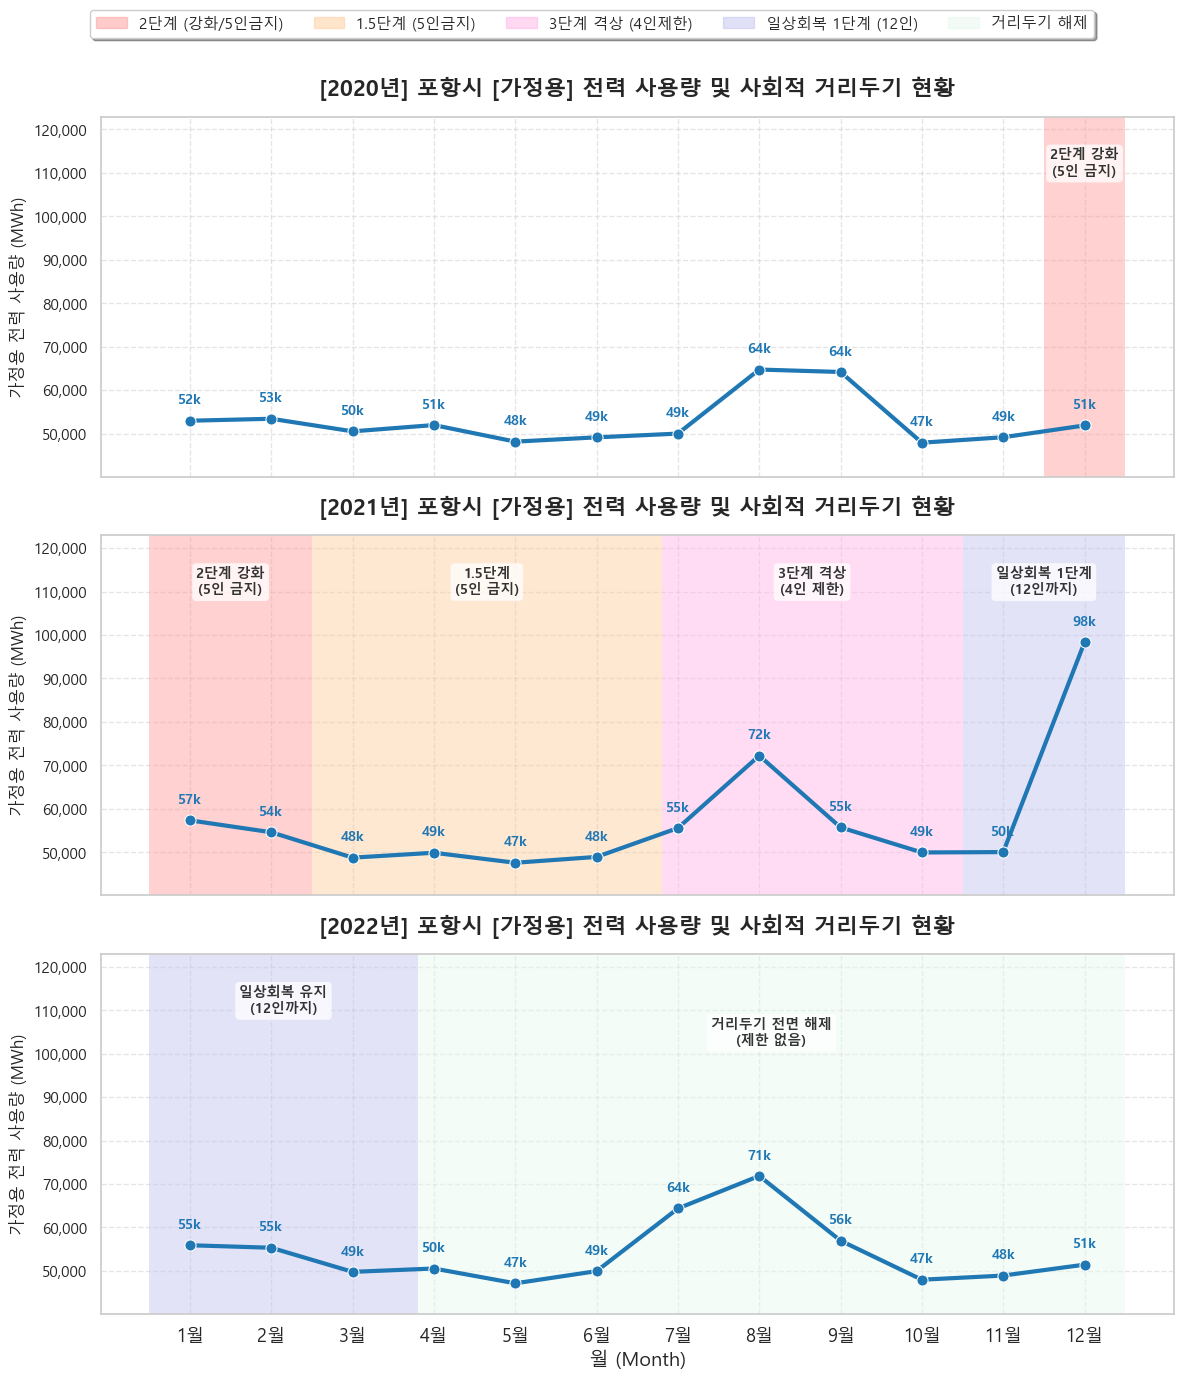

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

# 1. 폰트 및 시각화 환경 설정
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 2. 데이터 불러오기 및 전처리 (새로운 CSV 파일에 맞게 수정!)
try:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='cp949')

years = [2020, 2021, 2022]

# ★ 핵심: 새 파일에서 '가정용_사용량' 데이터만 추출
home_usage = pd.DataFrame({'월': range(1, 13)})
for year in years:
    year_data = df[df['연도'] == year].sort_values('월')
    home_usage[str(year)] = year_data['가정용_사용량'].values

# 3. Y축 범위 자동 조정 세팅 (바닥 뚫림 현상 방지)
max_val = home_usage[[str(y) for y in years]].max().max()
min_val = home_usage[[str(y) for y in years]].min().min()

# 하한선을 실제 데이터의 최소값보다 15% 낮게 설정
y_min = min_val * 0.85 
y_max = max_val * 1.25 # 상단 배경색 라벨 여백 확보

# 4. 거리두기 표 기반 구간 및 색상 재설정
COLOR_P1 = '#ff9999' # 2단계 (강화)
COLOR_P2 = '#ffcc99' # 1.5단계
COLOR_P3 = '#ffb3e6' # 3단계
COLOR_P4 = '#c2c2f0' # 일상회복 1단계
COLOR_P5 = '#e6f9ec' # 거리두기 해제

distancing_periods = {
    '2020': [
        (11.5, 12.5, COLOR_P1, '2단계 강화\n(5인 금지)') 
    ],
    '2021': [
        (0.5, 2.5, COLOR_P1, '2단계 강화\n(5인 금지)'),    
        (2.5, 6.8, COLOR_P2, '1.5단계\n(5인 금지)'),        
        (6.8, 10.5, COLOR_P3, '3단계 격상\n(4인 제한)'),      
        (10.5, 12.5, COLOR_P4, '일상회복 1단계\n(12인까지)') 
    ],
    '2022': [
        (0.5, 3.8, COLOR_P4, '일상회복 유지\n(12인까지)'),    
        (3.8, 12.5, COLOR_P5, '거리두기 전면 해제\n(제한 없음)') 
    ]
}

# 5. 시각화 그리기
fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

for i, year in enumerate([str(y) for y in years]):
    ax = axes[i]
    
    # Y축 고정 (자동 계산된 y_min, y_max 적용)
    ax.set_ylim(y_min, y_max)
    
    # 배경색 (axvspan) 및 라벨 달기
    if year in distancing_periods:
        for start, end, color, label in distancing_periods[year]:
            ax.axvspan(start, end, color=color, alpha=0.45, lw=0)
            
            y_pos = y_max * 0.94 if '해제' not in label else y_max * 0.88
            
            ax.text((start+end)/2, y_pos, label, 
                    ha='center', va='top', fontsize=10, fontweight='bold', color='#333333', 
                    bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.3'))

    # 가정용 전력 선 그래프 (파란색)
    sns.lineplot(data=home_usage, x='월', y=year, marker='o', ax=ax, color='#1f77b4', linewidth=3, markersize=8)
    
    ax.set_title(f'[{year}년] 포항시 [가정용] 전력 사용량 및 사회적 거리두기 현황', fontsize=16, fontweight='bold', pad=15)
    ax.set_ylabel('가정용 전력 사용량 (MWh)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    
    # 데이터 라벨 달기
    for x, y in zip(home_usage['월'], home_usage[year]):
        ax.annotate(f'{int(y/1000)}k', (x, y), textcoords="offset points", xytext=(0,12), ha='center', fontsize=10, color='#1f77b4', fontweight='bold')

# 범례(Legend) 붙이기
legend_patches = [
    mpatches.Patch(color=COLOR_P1, alpha=0.5, label='2단계 (강화/5인금지)'),
    mpatches.Patch(color=COLOR_P2, alpha=0.5, label='1.5단계 (5인금지)'),
    mpatches.Patch(color=COLOR_P3, alpha=0.5, label='3단계 격상 (4인제한)'),
    mpatches.Patch(color=COLOR_P4, alpha=0.5, label='일상회복 1단계 (12인)'),
    mpatches.Patch(color=COLOR_P5, alpha=0.5, label='거리두기 해제')
]
fig.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, 0.99), 
           ncol=5, fontsize=11, frameon=True, shadow=True)

# 축 세팅
plt.xticks(range(1, 13), [f'{m}월' for m in range(1, 13)], fontsize=13)
plt.xlabel('월 (Month)', fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

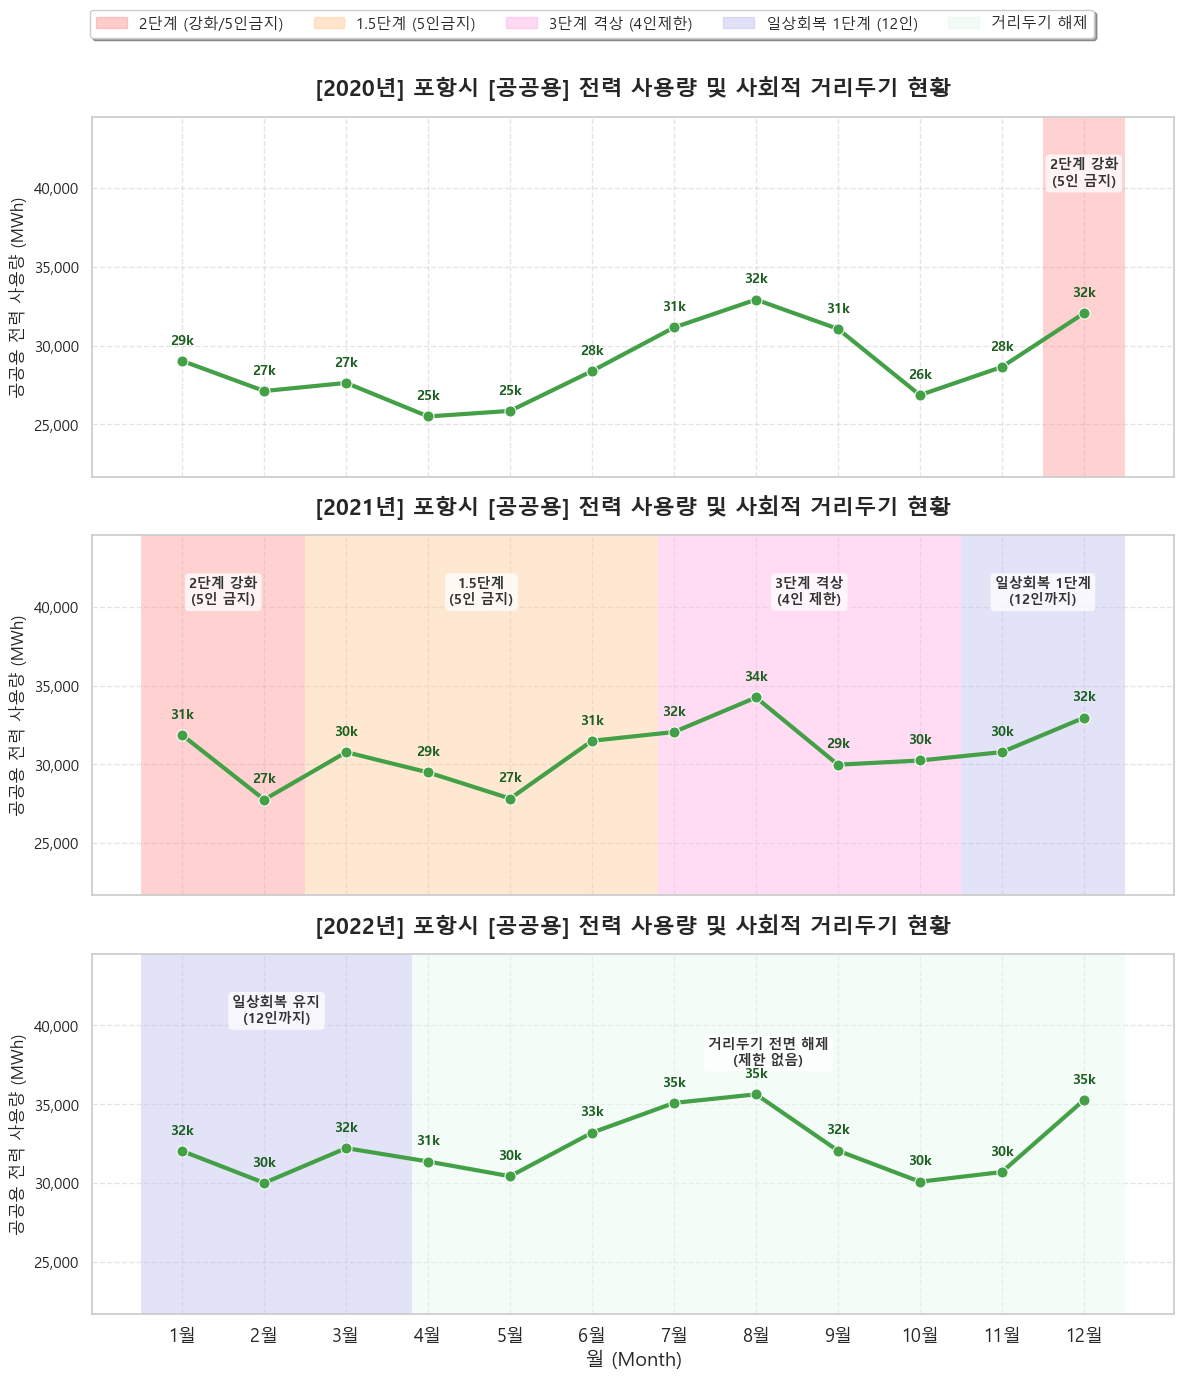

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

# 1. 폰트 및 시각화 환경 설정
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 2. 데이터 불러오기 및 전처리 (새로운 CSV 파일에 맞게 수정!)
try:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='cp949')

years = [2020, 2021, 2022]

# ★ 핵심: 새 파일에서 '공공용_사용량' 데이터만 추출
public_usage = pd.DataFrame({'월': range(1, 13)})
for year in years:
    year_data = df[df['연도'] == year].sort_values('월')
    public_usage[str(year)] = year_data['공공용_사용량'].values

# 3. Y축 범위 자동 조정 세팅 (바닥 뚫림 방지)
max_val = public_usage[[str(y) for y in years]].max().max()
min_val = public_usage[[str(y) for y in years]].min().min()

# 하한선을 실제 데이터의 최소값보다 15% 낮게 설정
y_min = min_val * 0.85 
y_max = max_val * 1.25 # 상단 배경색 라벨 여백 확보

# 4. 거리두기 표 기반 구간 및 색상 재설정
COLOR_P1 = '#ff9999' # 2단계 (강화)
COLOR_P2 = '#ffcc99' # 1.5단계
COLOR_P3 = '#ffb3e6' # 3단계
COLOR_P4 = '#c2c2f0' # 일상회복 1단계
COLOR_P5 = '#e6f9ec' # 거리두기 해제

distancing_periods = {
    '2020': [
        (11.5, 12.5, COLOR_P1, '2단계 강화\n(5인 금지)') 
    ],
    '2021': [
        (0.5, 2.5, COLOR_P1, '2단계 강화\n(5인 금지)'),    
        (2.5, 6.8, COLOR_P2, '1.5단계\n(5인 금지)'),        
        (6.8, 10.5, COLOR_P3, '3단계 격상\n(4인 제한)'),      
        (10.5, 12.5, COLOR_P4, '일상회복 1단계\n(12인까지)') 
    ],
    '2022': [
        (0.5, 3.8, COLOR_P4, '일상회복 유지\n(12인까지)'),    
        (3.8, 12.5, COLOR_P5, '거리두기 전면 해제\n(제한 없음)') 
    ]
}

# 5. 시각화 그리기
fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)
public_color = '#43a047' # 공공용 테마 컬러 (초록색)

for i, year in enumerate([str(y) for y in years]):
    ax = axes[i]
    
    # 수정된 Y축 고정값 적용
    ax.set_ylim(y_min, y_max)
    
    # 배경색 (axvspan) 및 라벨 달기
    if year in distancing_periods:
        for start, end, color, label in distancing_periods[year]:
            ax.axvspan(start, end, color=color, alpha=0.45, lw=0)
            
            y_pos = y_max * 0.94 if '해제' not in label else y_max * 0.88
            
            ax.text((start+end)/2, y_pos, label, 
                    ha='center', va='top', fontsize=10, fontweight='bold', color='#333333', 
                    bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.3'))

    # 공공용 전력 선 그래프
    sns.lineplot(data=public_usage, x='월', y=str(year), marker='o', ax=ax, color=public_color, linewidth=3, markersize=8)
    
    ax.set_title(f'[{year}년] 포항시 [공공용] 전력 사용량 및 사회적 거리두기 현황', fontsize=16, fontweight='bold', pad=15)
    ax.set_ylabel('공공용 전력 사용량 (MWh)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    
    # 데이터 라벨 달기
    for x, y in zip(public_usage['월'], public_usage[str(year)]):
        ax.annotate(f'{int(y/1000)}k', (x, y), textcoords="offset points", xytext=(0,12), ha='center', fontsize=10, color='#1b5e20', fontweight='bold')

# 범례(Legend) 붙이기
legend_patches = [
    mpatches.Patch(color=COLOR_P1, alpha=0.5, label='2단계 (강화/5인금지)'),
    mpatches.Patch(color=COLOR_P2, alpha=0.5, label='1.5단계 (5인금지)'),
    mpatches.Patch(color=COLOR_P3, alpha=0.5, label='3단계 격상 (4인제한)'),
    mpatches.Patch(color=COLOR_P4, alpha=0.5, label='일상회복 1단계 (12인)'),
    mpatches.Patch(color=COLOR_P5, alpha=0.5, label='거리두기 해제')
]
fig.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, 0.99), 
           ncol=5, fontsize=11, frameon=True, shadow=True)

# 축 세팅
plt.xticks(range(1, 13), [f'{m}월' for m in range(1, 13)], fontsize=13)
plt.xlabel('월 (Month)', fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

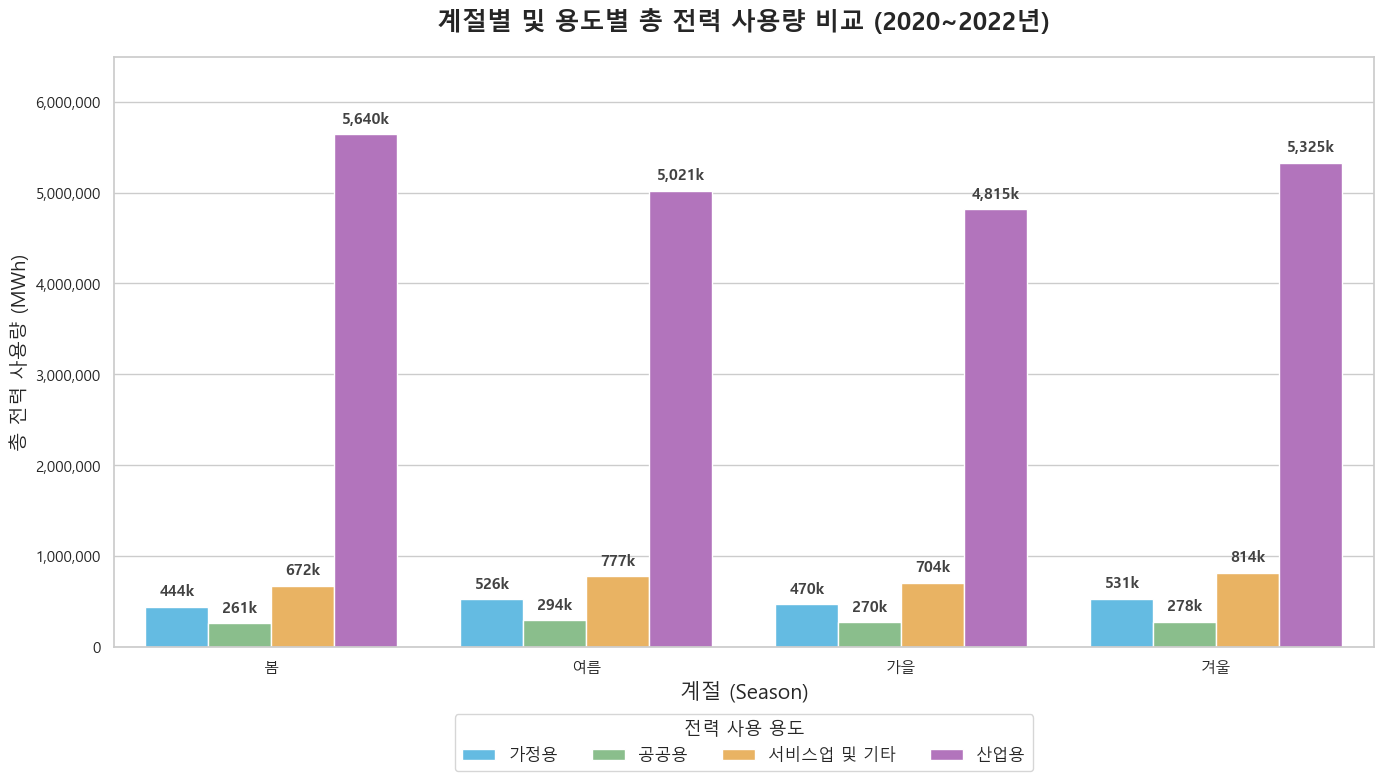

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 폰트 및 시각화 환경 설정 (윈도우 맑은 고딕 기준)
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 2. 데이터 불러오기 (새로운 CSV 파일)
try:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='cp949')

# 3. 데이터 전처리: '월'을 기준으로 '계절' 컬럼 생성 함수
def get_season(month):
    if month in [3, 4, 5]:
        return '봄'
    elif month in [6, 7, 8]:
        return '여름'
    elif month in [9, 10, 11]:
        return '가을'
    else: # 12, 1, 2
        return '겨울'

# 새롭게 '계절'이라는 파생 변수(컬럼) 생성
df['계절'] = df['월'].apply(get_season)

# 4. 이전 그래프들과 일관성을 위해 2020~2022년 데이터만 필터링
df_filtered = df[df['연도'].isin([2020, 2021, 2022])]

# 계절별 + 용도별 그룹화 및 합산
season_grouped = df_filtered.groupby('계절')[['가정용_사용량', '공공용_사용량', '서비스업_사용량', '산업용_사용량']].sum().reset_index()

# 5. Seaborn 시각화를 위해 가로로 긴 데이터를 세로로 '녹이기(Melt)'
df_melted = season_grouped.melt(id_vars='계절', var_name='용도', value_name='사용량')

# 카테고리 이름 깔끔하게 변경
rename_map = {
    '가정용_사용량': '가정용',
    '공공용_사용량': '공공용',
    '서비스업_사용량': '서비스업 및 기타',
    '산업용_사용량': '산업용'
}
df_melted['용도'] = df_melted['용도'].map(rename_map)

# 6. 시각화 세팅
plt.figure(figsize=(14, 8))

# x축 출력 순서를 봄->여름->가을->겨울로 강제 고정
season_order = ['봄', '여름', '가을', '겨울']

# 이전 그래프들과 완벽하게 동일한 컬러 매핑 적용
custom_palette = {
    '산업용': '#ba68c8',        # 보라색
    '서비스업 및 기타': '#ffb74d',  # 주황색
    '가정용': '#4fc3f7',        # 파란색
    '공공용': '#81c784'         # 초록색
}

# 그룹 막대 그래프(Grouped Bar Chart) 그리기
ax = sns.barplot(data=df_melted, x='계절', y='사용량', hue='용도', order=season_order, palette=custom_palette)

# 7. 그래프 꾸미기
plt.title('계절별 및 용도별 총 전력 사용량 비교 (2020~2022년)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('계절 (Season)', fontsize=15)
plt.ylabel('총 전력 사용량 (MWh)', fontsize=14)

# Y축 콤마 포맷팅
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 막대 위에 수치 라벨 추가 (보기 좋게 1,000 단위인 k로 축약)
for p in ax.patches:
    height = p.get_height()
    if height > 0: # 값이 있는 막대만 라벨링
        ax.annotate(f'{int(height/1000):,}k', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), textcoords='offset points',
                    fontsize=11, fontweight='bold', color='#424242')

# 범례 설정 (그래프와 겹치지 않게 하단으로 배치)
plt.legend(title='전력 사용 용도', fontsize=12, title_fontsize=13, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)

# Y축 텍스트 잘림 방지용 여백 추가
plt.ylim(0, df_melted['사용량'].max() * 1.15) 
plt.tight_layout()
plt.show()

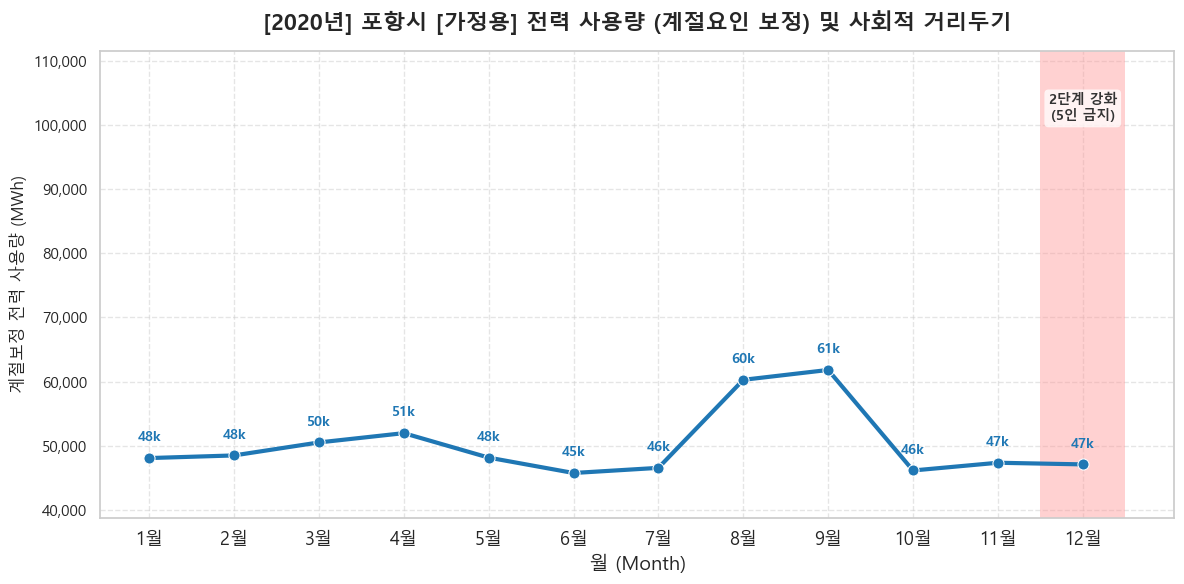

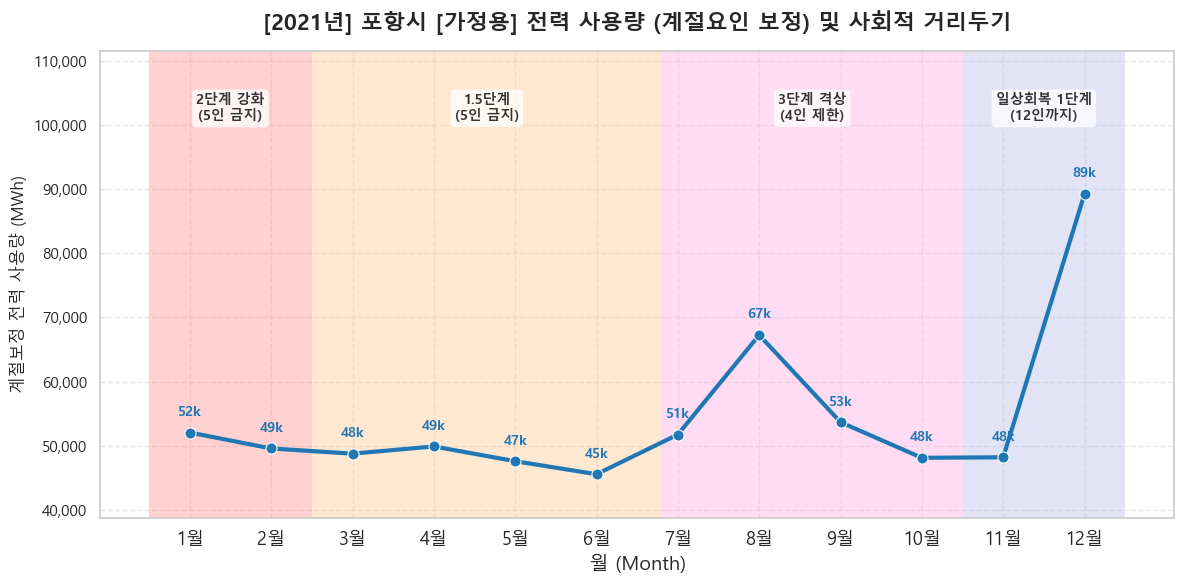

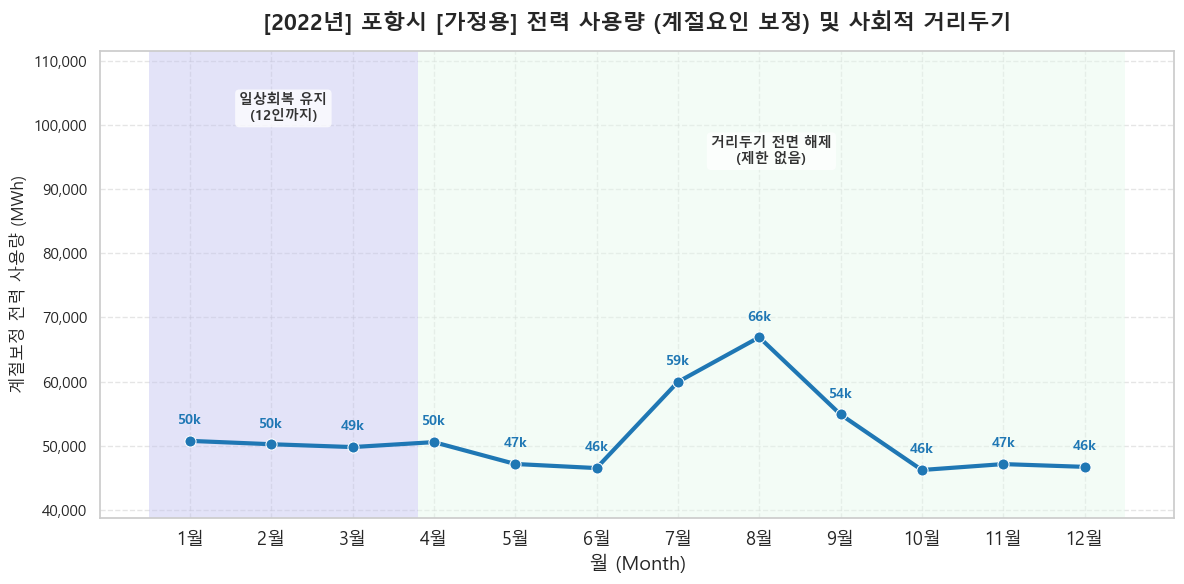

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

# 1. 폰트 및 시각화 환경 설정
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 2. 데이터 불러오기
try:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='cp949')

years = [2020, 2021, 2022]

# ★ 추가: 가정용 계절별 보정 배율 딕셔너리 (봄=1.0 기준)
# 겨울(12,1,2월), 봄(3,4,5월), 여름(6,7,8월), 가을(9,10,11월)
multipliers = {
    1: 0.9078, 2: 0.9078, 3: 1.0000, 4: 1.0000, 5: 1.0000, 6: 0.9311,
    7: 0.9311, 8: 0.9311, 9: 0.9632, 10: 0.9632, 11: 0.9632, 12: 0.9078
}

# ★ 핵심 수정 파트: 추출 시 월별 보정 배율 곱하기
home_usage = pd.DataFrame({'월': range(1, 13)})
for year in years:
    year_data = df[df['연도'] == year].sort_values('월').copy()
    
    # 람다 함수를 통해 각 월에 해당하는 배율을 곱해서 계절 영향을 제거
    year_data['가정용_보정사용량'] = year_data.apply(
        lambda row: row['가정용_사용량'] * multipliers[row['월']], axis=1
    )
    
    home_usage[str(year)] = year_data['가정용_보정사용량'].values

# 3. Y축 범위 자동 조정 세팅 (바닥 뚫림 현상 방지, 3개 연도 스케일 통일)
max_val = home_usage[[str(y) for y in years]].max().max()
min_val = home_usage[[str(y) for y in years]].min().min()

y_min = min_val * 0.85 
y_max = max_val * 1.25 # 상단 배경색 라벨 여백 확보

# 4. 거리두기 표 기반 구간 및 색상 재설정
COLOR_P1 = '#ff9999' # 2단계 (강화)
COLOR_P2 = '#ffcc99' # 1.5단계
COLOR_P3 = '#ffb3e6' # 3단계
COLOR_P4 = '#c2c2f0' # 일상회복 1단계
COLOR_P5 = '#e6f9ec' # 거리두기 해제

distancing_periods = {
    '2020': [(11.5, 12.5, COLOR_P1, '2단계 강화\n(5인 금지)')],
    '2021': [
        (0.5, 2.5, COLOR_P1, '2단계 강화\n(5인 금지)'),    
        (2.5, 6.8, COLOR_P2, '1.5단계\n(5인 금지)'),        
        (6.8, 10.5, COLOR_P3, '3단계 격상\n(4인 제한)'),       
        (10.5, 12.5, COLOR_P4, '일상회복 1단계\n(12인까지)') 
    ],
    '2022': [
        (0.5, 3.8, COLOR_P4, '일상회복 유지\n(12인까지)'),    
        (3.8, 12.5, COLOR_P5, '거리두기 전면 해제\n(제한 없음)') 
    ]
}

# 5. 시각화 그리기 (PPT용으로 각각 1개씩 총 3번 그리기)
for year_str in [str(y) for y in years]:
    fig, ax = plt.subplots(figsize=(12, 6)) # PPT에 꽉 차게 들어가는 가로형 비율
    
    # Y축 고정 (모든 연도 동일 스케일)
    ax.set_ylim(y_min, y_max)
    
    # 배경색 (axvspan) 및 라벨 달기
    if year_str in distancing_periods:
        for start, end, color, label in distancing_periods[year_str]:
            ax.axvspan(start, end, color=color, alpha=0.45, lw=0)
            
            y_pos = y_max * 0.94 if '해제' not in label else y_max * 0.88
            
            ax.text((start+end)/2, y_pos, label, 
                    ha='center', va='top', fontsize=10, fontweight='bold', color='#333333', 
                    bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.3'))

    # 가정용 전력 선 그래프 (파란색)
    sns.lineplot(x=home_usage['월'], y=home_usage[year_str], marker='o', ax=ax, color='#1f77b4', linewidth=3, markersize=8)
    
    # 그래프 꾸미기 (제목에 '계절요인 보정' 명시)
    ax.set_title(f'[{year_str}년] 포항시 [가정용] 전력 사용량 (계절요인 보정) 및 사회적 거리두기', fontsize=16, fontweight='bold', pad=15)
    ax.set_ylabel('계절보정 전력 사용량 (MWh)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    
    # 데이터 라벨 달기 (글씨 색상 통일)
    for x, y in zip(home_usage['월'], home_usage[year_str]):
        ax.annotate(f'{int(y/1000)}k', (x, y), textcoords="offset points", xytext=(0,12), 
                    ha='center', fontsize=10, color='#1f77b4', fontweight='bold')


    # 축 세팅
    plt.xticks(range(1, 13), [f'{m}월' for m in range(1, 13)], fontsize=13)
    plt.xlabel('월 (Month)', fontsize=14)

    plt.tight_layout()
    
    # 각각의 이미지 파일로 저장
    plt.savefig(f'포항시_가정용_전력_계절보정_{year_str}.png', dpi=300)
    plt.show()

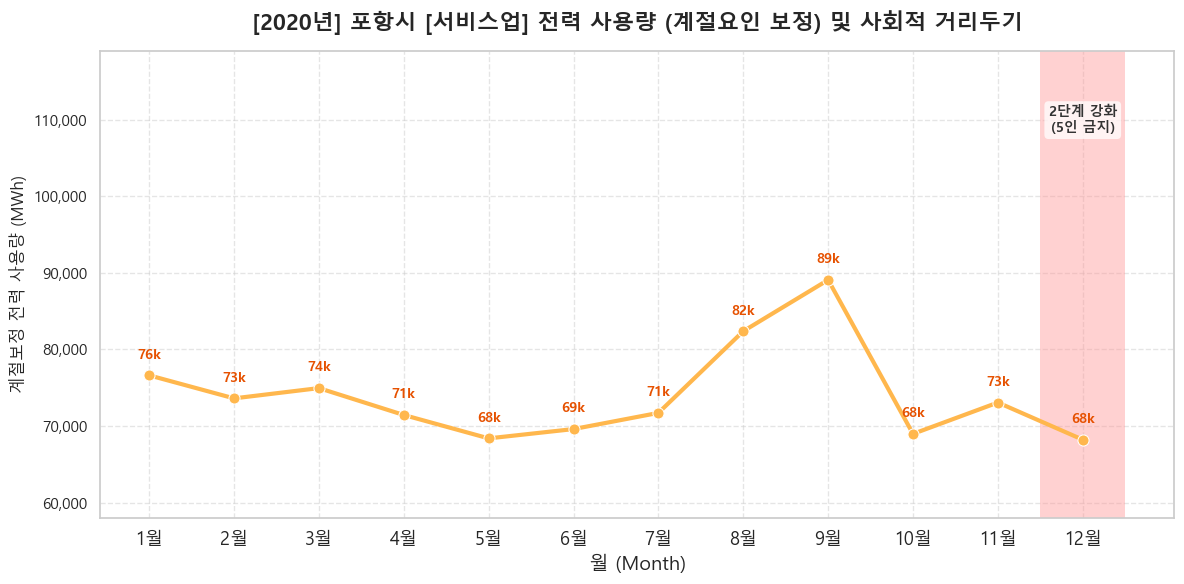

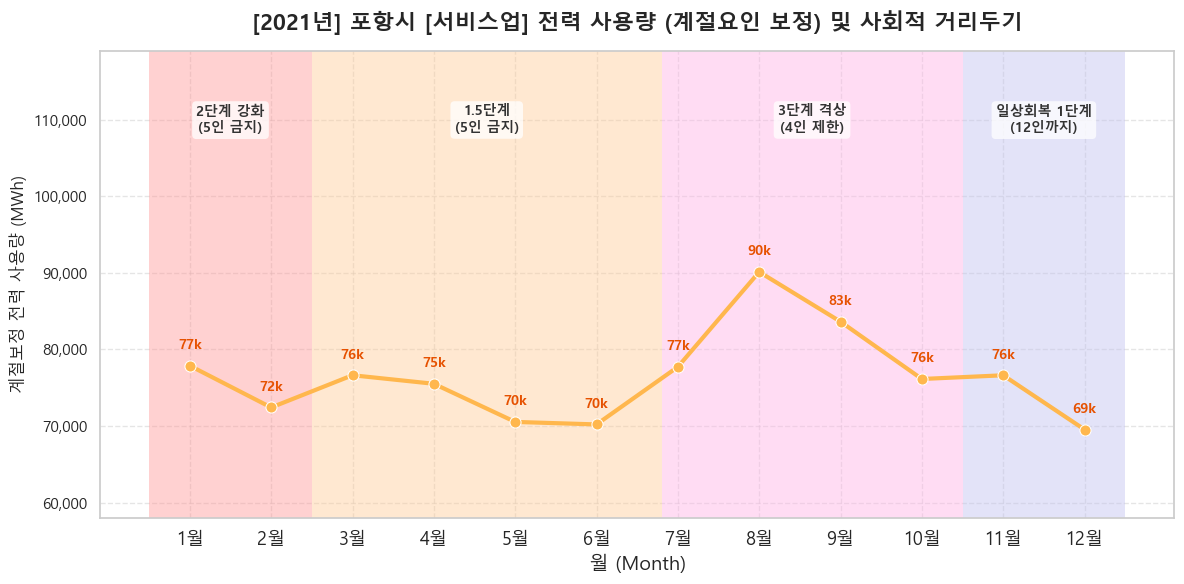

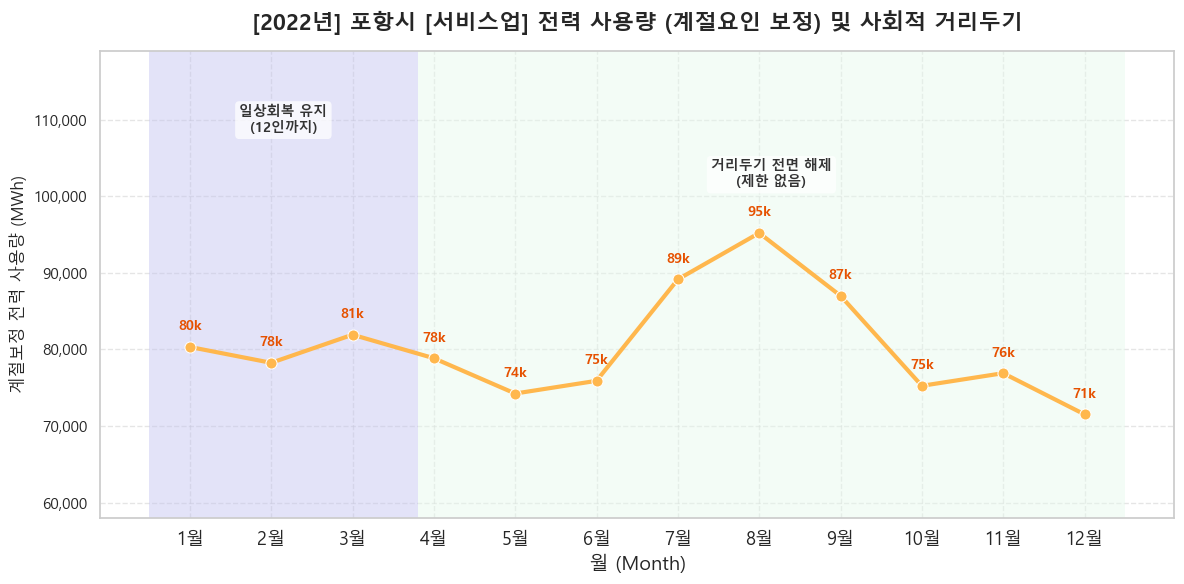

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

# 1. 폰트 및 시각화 환경 설정
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 2. 데이터 불러오기
try:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='cp949')

years = [2020, 2021, 2022]

# ★ 추가: 서비스업 계절별 보정 배율 딕셔너리 (봄=1.0 기준)
# 앞서 분석한 데이터: 봄(1.0), 여름(0.9292), 가을(1.0031), 겨울(0.8211)
multipliers = {
    1: 0.8211, 2: 0.8211, 3: 1.0000, 4: 1.0000, 5: 1.0000, 6: 0.9292,
    7: 0.9292, 8: 0.9292, 9: 1.0031, 10: 1.0031, 11: 1.0031, 12: 0.8211
}

# ★ 핵심 수정 파트: 추출 시 월별 보정 배율 곱하기
service_usage = pd.DataFrame({'월': range(1, 13)})
for year in years:
    year_data = df[df['연도'] == year].sort_values('월').copy()
    
    # 람다 함수를 통해 각 월에 해당하는 서비스업 배율을 곱해서 계절 영향을 제거
    year_data['서비스업_보정사용량'] = year_data.apply(
        lambda row: row['서비스업_사용량'] * multipliers[row['월']], axis=1
    )
    
    service_usage[str(year)] = year_data['서비스업_보정사용량'].values

# 3. Y축 범위 자동 조정 세팅 (바닥 뚫림 현상 방지, 3개 연도 스케일 통일)
max_val = service_usage[[str(y) for y in years]].max().max()
min_val = service_usage[[str(y) for y in years]].min().min()

y_min = min_val * 0.85 
y_max = max_val * 1.25 # 상단 배경색 라벨 여백 확보

# 4. 거리두기 표 기반 구간 및 색상 재설정
COLOR_P1 = '#ff9999' # 2단계 (강화)
COLOR_P2 = '#ffcc99' # 1.5단계
COLOR_P3 = '#ffb3e6' # 3단계
COLOR_P4 = '#c2c2f0' # 일상회복 1단계
COLOR_P5 = '#e6f9ec' # 거리두기 해제

distancing_periods = {
    '2020': [(11.5, 12.5, COLOR_P1, '2단계 강화\n(5인 금지)')],
    '2021': [
        (0.5, 2.5, COLOR_P1, '2단계 강화\n(5인 금지)'),    
        (2.5, 6.8, COLOR_P2, '1.5단계\n(5인 금지)'),        
        (6.8, 10.5, COLOR_P3, '3단계 격상\n(4인 제한)'),       
        (10.5, 12.5, COLOR_P4, '일상회복 1단계\n(12인까지)') 
    ],
    '2022': [
        (0.5, 3.8, COLOR_P4, '일상회복 유지\n(12인까지)'),    
        (3.8, 12.5, COLOR_P5, '거리두기 전면 해제\n(제한 없음)') 
    ]
}

# 5. 시각화 그리기 (PPT용으로 각각 1개씩 총 3번 그리기)
service_color = '#ffb74d' # 서비스업 테마 컬러 (주황색)

for year_str in [str(y) for y in years]:
    fig, ax = plt.subplots(figsize=(12, 6)) # PPT에 꽉 차게 들어가는 가로형 비율
    
    # Y축 고정 (모든 연도 동일 스케일)
    ax.set_ylim(y_min, y_max)
    
    # 배경색 (axvspan) 및 라벨 달기
    if year_str in distancing_periods:
        for start, end, color, label in distancing_periods[year_str]:
            ax.axvspan(start, end, color=color, alpha=0.45, lw=0)
            
            y_pos = y_max * 0.94 if '해제' not in label else y_max * 0.88
            
            ax.text((start+end)/2, y_pos, label, 
                    ha='center', va='top', fontsize=10, fontweight='bold', color='#333333', 
                    bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.3'))

    # 서비스업 전력 선 그래프
    sns.lineplot(x=service_usage['월'], y=service_usage[year_str], marker='o', ax=ax, color=service_color, linewidth=3, markersize=8)
    
    # 그래프 꾸미기 (제목에 '계절요인 보정' 명시)
    ax.set_title(f'[{year_str}년] 포항시 [서비스업] 전력 사용량 (계절요인 보정) 및 사회적 거리두기', fontsize=16, fontweight='bold', pad=15)
    ax.set_ylabel('계절보정 전력 사용량 (MWh)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    
    # 데이터 라벨 달기 (글씨 색상 통일)
    for x, y in zip(service_usage['월'], service_usage[year_str]):
        ax.annotate(f'{int(y/1000)}k', (x, y), textcoords="offset points", xytext=(0,12), 
                    ha='center', fontsize=10, color='#e65100', fontweight='bold')



    # 축 세팅
    plt.xticks(range(1, 13), [f'{m}월' for m in range(1, 13)], fontsize=13)
    plt.xlabel('월 (Month)', fontsize=14)

    plt.tight_layout()
    
    # 각각의 이미지 파일로 저장
    plt.savefig(f'포항시_서비스업_전력_계절보정_{year_str}.png', dpi=300)
    plt.show()

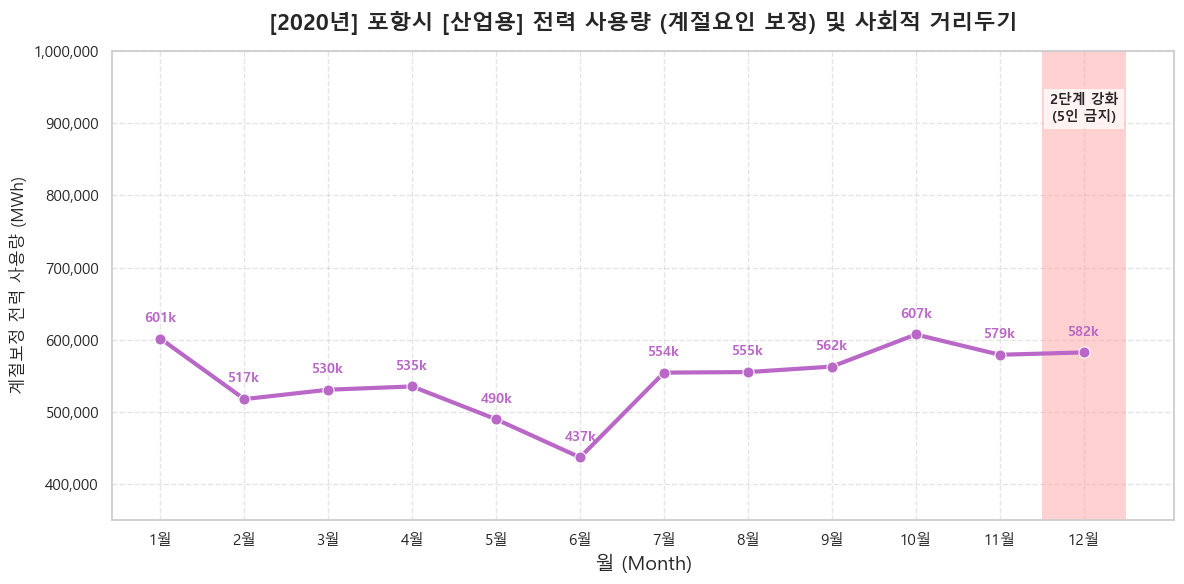

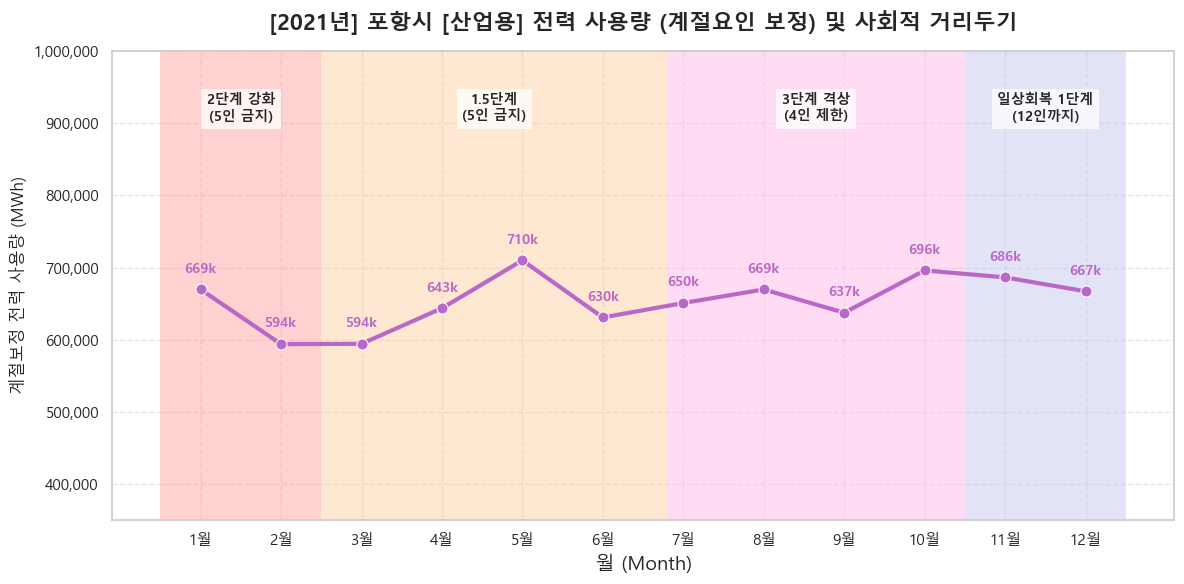

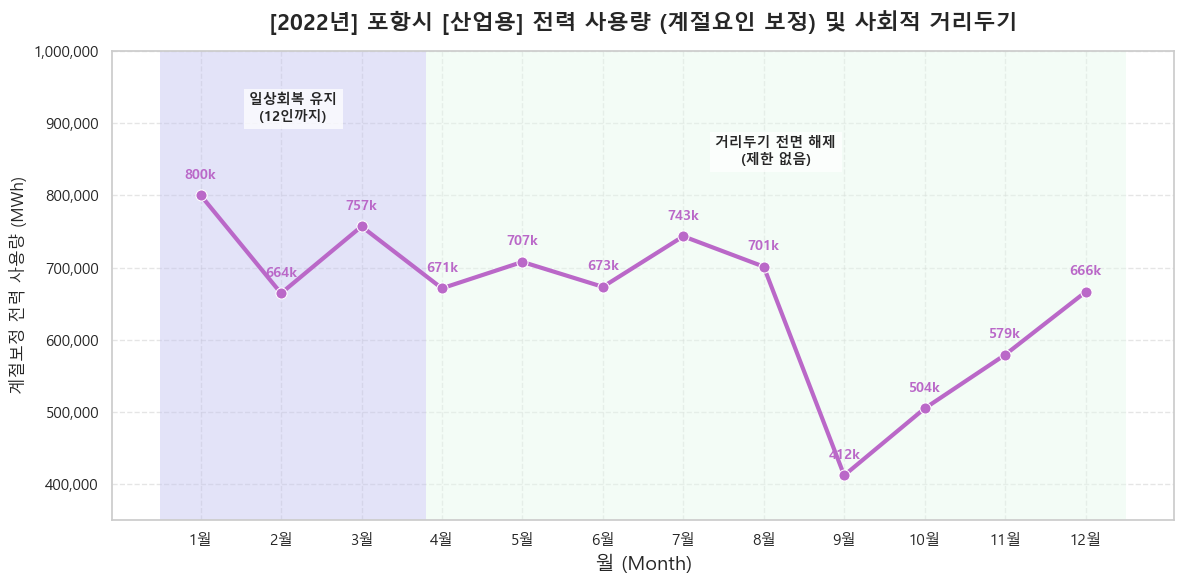

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

# 1. 폰트 및 시각화 환경 설정
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 2. 데이터 불러오기
try:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='cp949')

years = [2020, 2021, 2022]

# ★ 추가: 산업용 계절별 보정 배율 딕셔너리 (봄=1.0 기준)
# 앞서 분석한 데이터: 봄(1.0000), 여름(1.1186), 가을(1.0936), 겨울(1.0823)
multipliers = {
    1: 1.0823, 2: 1.0823, 3: 1.0000, 4: 1.0000, 5: 1.0000, 6: 1.1186,
    7: 1.1186, 8: 1.1186, 9: 1.0936, 10: 1.0936, 11: 1.0936, 12: 1.0823
}

# ★ 핵심 수정 파트: 추출 시 월별 보정 배율 곱하기
ind_usage = pd.DataFrame({'월': range(1, 13)})
for year in years:
    year_data = df[df['연도'] == year].sort_values('월').copy()
    
    # 람다 함수를 통해 각 월에 해당하는 산업용 배율을 곱해서 계절 영향을 제거
    year_data['산업용_보정사용량'] = year_data.apply(
        lambda row: row['산업용_사용량'] * multipliers[row['월']], axis=1
    )
    
    ind_usage[str(year)] = year_data['산업용_보정사용량'].values

# 3. Y축 범위 자동 조정 세팅 (모든 연도 스케일 통일)
max_val = ind_usage[[str(y) for y in years]].max().max()
min_val = ind_usage[[str(y) for y in years]].min().min()

y_min = min_val * 0.85 
y_max = max_val * 1.25 # 상단 배경색 라벨 여백 확보

# 4. 거리두기 표 기반 구간 및 색상 재설정
COLOR_P1 = '#ff9999' # 2단계 (강화)
COLOR_P2 = '#ffcc99' # 1.5단계
COLOR_P3 = '#ffb3e6' # 3단계
COLOR_P4 = '#c2c2f0' # 일상회복 1단계
COLOR_P5 = '#e6f9ec' # 거리두기 해제

distancing_periods = {
    '2020': [(11.5, 12.5, COLOR_P1, '2단계 강화\n(5인 금지)')],
    '2021': [
        (0.5, 2.5, COLOR_P1, '2단계 강화\n(5인 금지)'),
        (2.5, 6.8, COLOR_P2, '1.5단계\n(5인 금지)'),
        (6.8, 10.5, COLOR_P3, '3단계 격상\n(4인 제한)'),
        (10.5, 12.5, COLOR_P4, '일상회복 1단계\n(12인까지)')
    ],
    '2022': [
        (0.5, 3.8, COLOR_P4, '일상회복 유지\n(12인까지)'),
        (3.8, 12.5, COLOR_P5, '거리두기 전면 해제\n(제한 없음)')
    ]
}

# 5. 연도별 개별 그래프 생성 루프 (PPT용으로 각각 1개씩 총 3번 그리기)
ind_color = '#ba68c8' # 산업용 테마 컬러 (보라색)

for year_str in [str(y) for y in years]:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Y축 범위 고정
    ax.set_ylim(y_min, y_max)
    
    # 거리두기 배경색 및 라벨
    if year_str in distancing_periods:
        for start, end, color, label in distancing_periods[year_str]:
            ax.axvspan(start, end, color=color, alpha=0.45, lw=0)
            
            y_pos = y_max * 0.94 if '해제' not in label else y_max * 0.88
            ax.text((start+end)/2, y_pos, label, ha='center', va='top', fontsize=10, 
                    fontweight='bold', bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))

    # 산업용 전력 선 그래프 그리기
    sns.lineplot(x=ind_usage['월'], y=ind_usage[year_str], marker='o', ax=ax, color=ind_color, linewidth=3, markersize=8)
    
    # 그래프 꾸미기 (제목과 라벨에 '계절요인 보정' 명시)
    ax.set_title(f'[{year_str}년] 포항시 [산업용] 전력 사용량 (계절요인 보정) 및 사회적 거리두기', fontsize=16, fontweight='bold', pad=15)
    ax.set_ylabel('계절보정 전력 사용량 (MWh)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    
    # 수치 표시
    for x, y in zip(ind_usage['월'], ind_usage[year_str]):
        ax.annotate(f'{int(y/1000)}k', (x, y), textcoords="offset points", xytext=(0,12), 
                    ha='center', fontsize=10, color=ind_color, fontweight='bold')


    plt.xticks(range(1, 13), [f'{m}월' for m in range(1, 13)], fontsize=11)
    plt.xlabel('월 (Month)', fontsize=14)
    plt.tight_layout()
    
    # 파일 저장 (PPT 삽입용)
    plt.savefig(f'포항시_산업용_전력_계절보정_{year_str}.png', dpi=300)
    plt.show()

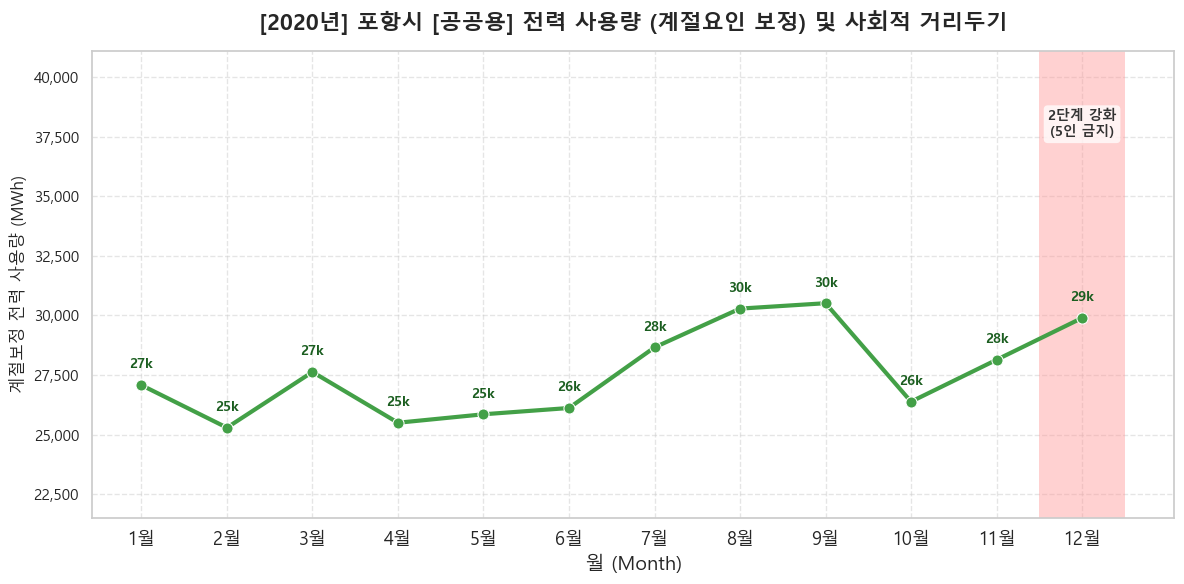

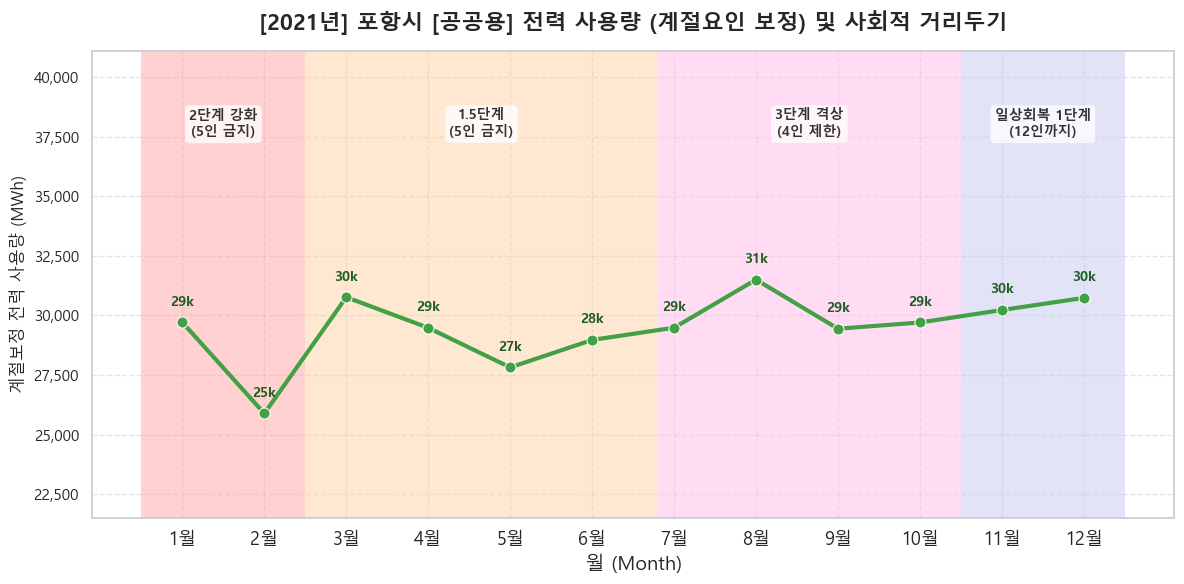

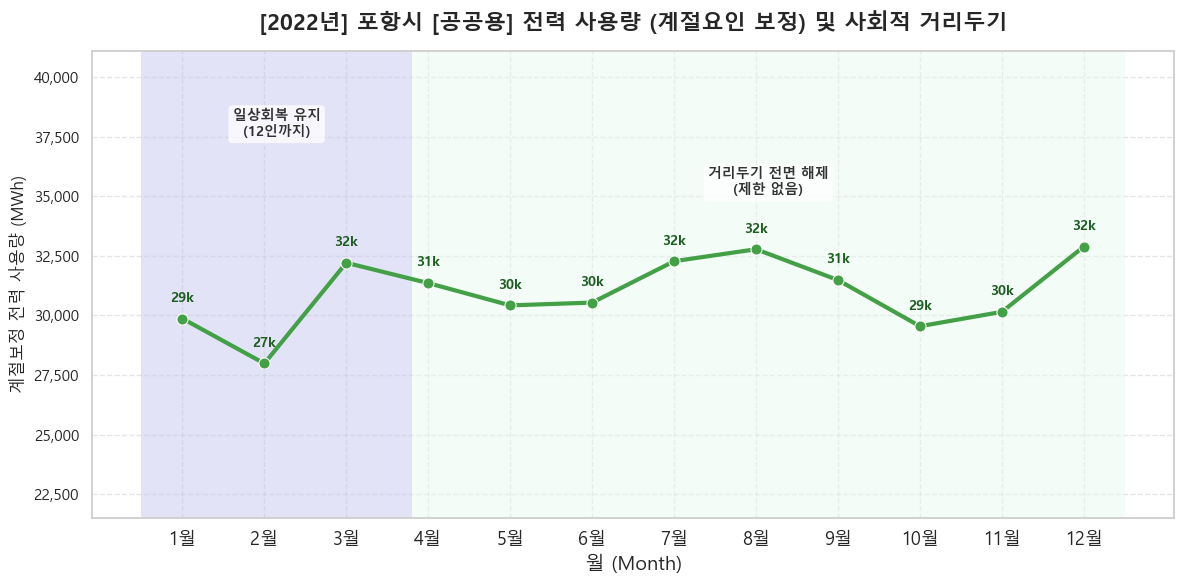

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

# 1. 폰트 및 시각화 환경 설정
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 2. 데이터 불러오기
try:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('포항시전력사용량_1923.csv', encoding='cp949')

years = [2020, 2021, 2022]

# ★ 추가: 공공용 계절별 보정 배율 딕셔너리 (봄=1.0 기준)
# 10년 평균 기준 보정 배율: 봄(1.0000), 여름(0.9201), 가을(0.9824), 겨울(0.9328)
multipliers = {
    1: 0.9328, 2: 0.9328, 3: 1.0000, 4: 1.0000, 5: 1.0000, 6: 0.9201,
    7: 0.9201, 8: 0.9201, 9: 0.9824, 10: 0.9824, 11: 0.9824, 12: 0.9328
}

# ★ 핵심 수정 파트: 추출 시 월별 공공용 보정 배율 곱하기
public_usage = pd.DataFrame({'월': range(1, 13)})
for year in years:
    year_data = df[df['연도'] == year].sort_values('월').copy()
    
    # 람다 함수를 통해 각 월에 해당하는 공공용 배율을 곱해서 계절 영향을 제거
    year_data['공공용_보정사용량'] = year_data.apply(
        lambda row: row['공공용_사용량'] * multipliers[row['월']], axis=1
    )
    
    public_usage[str(year)] = year_data['공공용_보정사용량'].values

# 3. Y축 범위 자동 조정 세팅 (모든 연도 스케일 통일)
max_val = public_usage[[str(y) for y in years]].max().max()
min_val = public_usage[[str(y) for y in years]].min().min()

y_min = min_val * 0.85 
y_max = max_val * 1.25 # 상단 배경색 라벨 여백 확보

# 4. 거리두기 표 기반 구간 및 색상 재설정
COLOR_P1 = '#ff9999' # 2단계 (강화)
COLOR_P2 = '#ffcc99' # 1.5단계
COLOR_P3 = '#ffb3e6' # 3단계
COLOR_P4 = '#c2c2f0' # 일상회복 1단계
COLOR_P5 = '#e6f9ec' # 거리두기 해제

distancing_periods = {
    '2020': [(11.5, 12.5, COLOR_P1, '2단계 강화\n(5인 금지)')],
    '2021': [
        (0.5, 2.5, COLOR_P1, '2단계 강화\n(5인 금지)'),    
        (2.5, 6.8, COLOR_P2, '1.5단계\n(5인 금지)'),        
        (6.8, 10.5, COLOR_P3, '3단계 격상\n(4인 제한)'),       
        (10.5, 12.5, COLOR_P4, '일상회복 1단계\n(12인까지)') 
    ],
    '2022': [
        (0.5, 3.8, COLOR_P4, '일상회복 유지\n(12인까지)'),    
        (3.8, 12.5, COLOR_P5, '거리두기 전면 해제\n(제한 없음)') 
    ]
}

# 5. 연도별 개별 그래프 생성 (PPT용 3개)
public_color = '#43a047' # 공공용 테마 컬러 (초록색)

for year_str in [str(y) for y in years]:
    fig, ax = plt.subplots(figsize=(12, 6)) # PPT용 가로 비율
    
    # 수정된 Y축 고정값 적용
    ax.set_ylim(y_min, y_max)
    
    # 배경색 (axvspan) 및 라벨 달기
    if year_str in distancing_periods:
        for start, end, color, label in distancing_periods[year_str]:
            ax.axvspan(start, end, color=color, alpha=0.45, lw=0)
            
            y_pos = y_max * 0.94 if '해제' not in label else y_max * 0.88
            
            ax.text((start+end)/2, y_pos, label, 
                    ha='center', va='top', fontsize=10, fontweight='bold', color='#333333', 
                    bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.3'))

    # 공공용 전력 선 그래프
    sns.lineplot(x=public_usage['월'], y=public_usage[year_str], marker='o', ax=ax, color=public_color, linewidth=3, markersize=8)
    
    # 그래프 꾸미기 (제목에 '계절요인 보정' 명시)
    ax.set_title(f'[{year_str}년] 포항시 [공공용] 전력 사용량 (계절요인 보정) 및 사회적 거리두기', fontsize=16, fontweight='bold', pad=15)
    ax.set_ylabel('계절보정 전력 사용량 (MWh)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    
    # 데이터 라벨 달기
    for x, y in zip(public_usage['월'], public_usage[year_str]):
        ax.annotate(f'{int(y/1000)}k', (x, y), textcoords="offset points", xytext=(0,12), 
                    ha='center', fontsize=10, color='#1b5e20', fontweight='bold')


    # 축 세팅
    plt.xticks(range(1, 13), [f'{m}월' for m in range(1, 13)], fontsize=13)
    plt.xlabel('월 (Month)', fontsize=14)

    plt.tight_layout()
    
    # 각각의 이미지 파일로 저장
    plt.savefig(f'포항시_공공용_전력_계절보정_{year_str}.png', dpi=300)
    plt.show()